# California CASTNET — Data Extraction (Complete)

**Purpose:** Extract, filter, and enrich CASTNET data for California sites only.  
**Outputs:** Site-filtered ozone, hourly gas, dry chemistry, wet chemistry, PurpleAir,
and enriched site metadata with static geographic features (elevation, coast distance, terrain class).

### What this notebook does
| Section | Action |
|---------|--------|
| 1–2 | Imports, paths, California site registry, coast-distance computation |
| 3 | Directory scan — maps every CSV to an extractor; flags unclaimed/missing files |
| 4 | Flexible file finder + CASTNET naming reference + empty-schema fallbacks |
| 5–10 | Extractor classes/functions for each data source |
| 11–12 | `CaliforniaDataLoader` orchestrator + execution |
| 13–15 | Completeness diagnostics, temporal coverage plots, site map |
| 16–17 | Save all outputs, final handoff status check |


## Section 1: Setup & Imports

In [30]:
import pandas as pd
import numpy as np
import os
import glob
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("Libraries loaded successfully.")
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")


Libraries loaded successfully.
pandas  : 2.2.2
numpy   : 1.26.4


## Section 2: Configuration & California Site Registry

In [31]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIRECTORY = r"C:\MATH699P\Data"
PROCESSED_DIR  = os.path.join(DATA_DIRECTORY, 'processed_data', 'california')
os.makedirs(PROCESSED_DIR, exist_ok=True)

print(f"Data Directory    : {DATA_DIRECTORY}")
print(f"Output Directory  : {PROCESSED_DIR}")


Data Directory    : C:\MATH699P\Data
Output Directory  : C:\MATH699P\Data\processed_data\california


In [32]:
# ── California CASTNET Site Registry (all 10 active sites) ────────────────────
CA_SITE_REGISTRY = {
    # ── Sierra Nevada ─────────────────────────────────────────────────────────
    'SEK402': {'display_name':'Sequoia NP',         'lat':36.4886,  'lon':-118.8284,
               'elevation_m':1920, 'terrain':'COMPLEX', 'land_use':'FORESTED',
               'region':'Sierra Nevada South'},
    'YOS404': {'display_name':'Yosemite NP',        'lat':37.7133,  'lon':-119.7069,
               'elevation_m':1603, 'terrain':'COMPLEX', 'land_use':'FORESTED',
               'region':'Sierra Nevada Central'},
    # ── Deserts / Inland South ────────────────────────────────────────────────
    'JOT403': {'display_name':'Joshua Tree NP',     'lat':34.0617,  'lon':-116.3873,
               'elevation_m':1244, 'terrain':'EXPOSED', 'land_use':'DESERT SHRUB',
               'region':'Mojave Desert'},
    # ── Northern California ───────────────────────────────────────────────────
    'LAV410': {'display_name':'Lassen Volcanic NP', 'lat':40.5402,  'lon':-121.5763,
               'elevation_m':1756, 'terrain':'COMPLEX', 'land_use':'FORESTED',
               'region':'Cascades'},
    'TRI193': {'display_name':'Trinity',            'lat':40.9603,  'lon':-122.9547,
               'elevation_m': 744, 'terrain':'COMPLEX', 'land_use':'FORESTED',
               'region':'Northern Coast Range'},
    # ── Central / South Coast ─────────────────────────────────────────────────
    'PIN414': {'display_name':'Pinnacles NP',       'lat':36.4855,  'lon':-121.1824,
               'elevation_m': 335, 'terrain':'SLOPED',  'land_use':'MIXED SHRUB',
               'region':'Central Coast'},
    # ── Southern California Mountains ─────────────────────────────────────────
    'SND152': {'display_name':'San Bernardino NF',  'lat':34.1939,  'lon':-116.7730,
               'elevation_m':1737, 'terrain':'COMPLEX', 'land_use':'FORESTED',
               'region':'Southern California Mountains'},
    'ABF404': {'display_name':'Angeles Big Bear',   'lat':34.2059,  'lon':-116.9113,
               'elevation_m':2065, 'terrain':'COMPLEX', 'land_use':'FORESTED',
               'region':'San Bernardino Mountains'},
    'SAN405': {'display_name':'San Gabriel',        'lat':34.2339,  'lon':-117.7610,
               'elevation_m':1161, 'terrain':'COMPLEX', 'land_use':'FORESTED',
               'region':'San Gabriel Mountains'},
    # ── Southern Coast ────────────────────────────────────────────────────────
    'CAN407': {'display_name':'Cabrillo NM',        'lat':32.6735,  'lon':-117.2425,
               'elevation_m':  80, 'terrain':'EXPOSED', 'land_use':'GRASSLAND',
               'region':'Southern Coast'},
}
CA_SITES = list(CA_SITE_REGISTRY.keys())

print(f"California CASTNET sites registered: {len(CA_SITES)}")
print("-" * 70)
for sid, meta in CA_SITE_REGISTRY.items():
    print(f"  {sid}  |  {meta['display_name']:<22s}  |  "
          f"Elev {meta['elevation_m']:>4d}m  |  {meta['region']}")


# Extended site list — includes 5 sites discovered from SITE.csv
# (CON186, DEV412, LPO010, SEK430, YOS204) not in the 10-site registry above.
# Used as the fallback site filter inside load_hourly_gas() and
# load_wet_concentration() when site_ids is not passed explicitly.
CA_SITES_REGISTRY_IDS = [
    'SEK402','YOS404','JOT403','LAV410','TRI193','PIN414',
    'SND152','ABF404','SAN405','CAN407','CON186','DEV412',
    'LPO010','SEK430','YOS204',
]
print(f"Extended site list: {len(CA_SITES_REGISTRY_IDS)} sites")

California CASTNET sites registered: 10
----------------------------------------------------------------------
  SEK402  |  Sequoia NP              |  Elev 1920m  |  Sierra Nevada South
  YOS404  |  Yosemite NP             |  Elev 1603m  |  Sierra Nevada Central
  JOT403  |  Joshua Tree NP          |  Elev 1244m  |  Mojave Desert
  LAV410  |  Lassen Volcanic NP      |  Elev 1756m  |  Cascades
  TRI193  |  Trinity                 |  Elev  744m  |  Northern Coast Range
  PIN414  |  Pinnacles NP            |  Elev  335m  |  Central Coast
  SND152  |  San Bernardino NF       |  Elev 1737m  |  Southern California Mountains
  ABF404  |  Angeles Big Bear        |  Elev 2065m  |  San Bernardino Mountains
  SAN405  |  San Gabriel             |  Elev 1161m  |  San Gabriel Mountains
  CAN407  |  Cabrillo NM             |  Elev   80m  |  Southern Coast
Extended site list: 15 sites


In [33]:
# ── Coast distance computation ─────────────────────────────────────────────────
CA_COASTLINE_POINTS = [
    (32.53,-117.13),(33.72,-118.29),(34.45,-119.69),(35.37,-120.86),
    (36.60,-121.89),(37.50,-122.51),(38.31,-123.05),(39.44,-123.80),
    (40.44,-124.40),(41.75,-124.20),
]

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat, dlon = radians(lat2-lat1), radians(lon2-lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

def min_distance_to_coast_km(lat, lon):
    return min(haversine_km(lat, lon, clat, clon) for clat, clon in CA_COASTLINE_POINTS)

for sid, meta in CA_SITE_REGISTRY.items():
    meta['coast_dist_km'] = round(min_distance_to_coast_km(meta['lat'], meta['lon']), 1)
    meta['marine_influence'] = (
        'COASTAL'    if meta['coast_dist_km'] < 100 else
        'TRANSITION' if meta['coast_dist_km'] < 200 else 'INLAND'
    )

print("Coast distances computed:")
print("-" * 60)
for sid, meta in CA_SITE_REGISTRY.items():
    print(f"  {sid}  {meta['display_name']:<22s}  "
          f"{meta['coast_dist_km']:>6.1f} km   [{meta['marine_influence']}]")


Coast distances computed:
------------------------------------------------------------
  SEK402  Sequoia NP               221.2 km   [INLAND]
  YOS404  Yosemite NP              229.7 km   [INLAND]
  JOT403  Joshua Tree NP           179.7 km   [TRANSITION]
  LAV410  Lassen Volcanic NP       225.5 km   [INLAND]
  TRI193  Trinity                  134.9 km   [TRANSITION]
  PIN414  Pinnacles NP              64.5 km   [COASTAL]
  SND152  San Bernardino NF        149.5 km   [TRANSITION]
  ABF404  Angeles Big Bear         138.2 km   [TRANSITION]
  SAN405  San Gabriel               75.1 km   [COASTAL]
  CAN407  Cabrillo NM               19.1 km   [COASTAL]


## Section 3: Directory Scan & File Status

Every CSV in `DATA_DIRECTORY` is mapped to its extractor using `EXTRACTOR_RULES`.
Files marked `⚠ UNCLAIMED` have no matching extractor — if they contain data
you need, add a pattern to `FILE_PATTERNS` in Section 4.
The **Required Table Status** block shows at a glance which of the 6 pipeline
tables are present and which need to be downloaded.


In [34]:
# ── Extractor name-matching rules (used for scan + inventory file) ─────────────
EXTRACTOR_RULES = {
    'OZONE'            : lambda b: b == 'ozone' or b.startswith('ozone_'),
    'HOURLY_GAS'       : lambda b: (b in ('hourly_gas','hourlygas')
                                    or ('hourly' in b and 'gas' in b)
                                    or b.startswith('gas_hourly')),
    'DRYCHEM'          : lambda b: b == 'drychem' or b.startswith('drychem_'),
    'DRYDEP_WEEK'      : lambda b: b.startswith('drydep'),
    'WET_CONCENTRATION': lambda b: (('wet' in b and 'concentration' in b)
                                    or ('wet' in b and 'chem' in b)
                                    or b in ('wetconcentration','wet_concentration')),
    'PURPLEAIR'        : lambda b: ('purpleair' in b or 'purple_air' in b
                                    or b.startswith('pa_web')
                                    or b.startswith('pm25_web')),
    'SITE'             : lambda b: b == 'site' or (b.startswith('site') and 'plant' not in b),
    'GAS_CALIBRATION'  : lambda b: 'calibration' in b,
    'CLOUD'            : lambda b: b.startswith('cloud'),
    'VISCHEM'          : lambda b: b == 'vischem',
    'VISNEPH'          : lambda b: b == 'visneph',
    'TOTAL_DEPOSITION' : lambda b: 'total_deposition' in b or 'totaldeposition' in b,
    'HISTORIC_AVERAGE' : lambda b: 'historic' in b,
}

REQUIRED_TABLES = {
    'OZONE'            : 'Hourly ozone target (ppb)',
    'HOURLY_GAS'       : 'Precursor gases for ozone formation',
    'DRYCHEM'          : 'Weekly filter-pack chemistry',
    'WET_CONCENTRATION': 'Weekly precipitation chemistry',
    'PURPLEAIR'        : 'PM2.5 wildfire smoke proxy',
    'SITE'             : 'Site metadata & coordinates',
}

print("=" * 80)
print("FULL DIRECTORY SCAN")
print("=" * 80)

if not os.path.exists(DATA_DIRECTORY):
    print(f"ERROR: {DATA_DIRECTORY} does not exist — check DATA_DIRECTORY path.")
else:
    all_csvs  = sorted(f for f in os.listdir(DATA_DIRECTORY) if f.lower().endswith('.csv'))
    claimed   = {}
    unclaimed = []
    print(f"Total CSV files: {len(all_csvs)}\n")

    for fn in all_csvs:
        base    = fn.lower().replace('.csv', '')
        size_mb = os.path.getsize(os.path.join(DATA_DIRECTORY, fn)) / (1024**2)
        matched = [ext for ext, rule in EXTRACTOR_RULES.items() if rule(base)]
        if matched:
            tag = matched[0]
            claimed.setdefault(tag, []).append(fn)
            print(f"  ✓  {fn:<50s}  {size_mb:6.2f} MB   → {tag}")
        else:
            unclaimed.append(fn)
            print(f"  ?  {fn:<50s}  {size_mb:6.2f} MB   ⚠ UNCLAIMED")

    print("\n" + "=" * 80)
    print("REQUIRED TABLE STATUS")
    print("=" * 80)
    for table, desc in REQUIRED_TABLES.items():
        files = claimed.get(table, [])
        if files:
            print(f"  ✅  {table:<22s}  {len(files)} file(s): {files[:3]}")
        else:
            print(f"  ❌  {table:<22s}  NOT FOUND  ← {desc}")

    if unclaimed:
        print("\n⚠  UNCLAIMED FILES — add a pattern to FILE_PATTERNS (Section 4) if needed:")
        for fn in unclaimed:
            size_mb = os.path.getsize(os.path.join(DATA_DIRECTORY, fn)) / (1024**2)
            print(f"    {fn:<50s}  {size_mb:6.2f} MB")

    # Save inventory text file
    inv_path = os.path.join(PROCESSED_DIR, 'ca_file_inventory.txt')
    with open(inv_path, 'w') as f:
        f.write(f"CASTNET File Inventory — {datetime.now():%Y-%m-%d %H:%M}\n")
        f.write(f"Directory: {DATA_DIRECTORY}\n\n")
        for tag, files in claimed.items():
            f.write(f"\n{tag}\n")
            for fn in files:
                sz = os.path.getsize(os.path.join(DATA_DIRECTORY, fn)) / (1024**2)
                f.write(f"  {fn}  ({sz:.2f} MB)\n")
        if unclaimed:
            f.write("\nUNCLAIMED\n")
            for fn in unclaimed:
                f.write(f"  {fn}\n")
    print(f"\nInventory saved → {inv_path}")


FULL DIRECTORY SCAN
Total CSV files: 106

  ✓  cloud_event.csv                                       0.42 MB   → CLOUD
  ✓  cloud_month.csv                                       0.02 MB   → CLOUD
  ✓  drychem.csv                                          32.24 MB   → DRYCHEM
  ✓  drydep_week_web.csv                                  35.33 MB   → DRYDEP_WEEK
  ✓  gas_calibration.csv                                  36.67 MB   → GAS_CALIBRATION
  ✓  gas_calibration_web.csv                              11.25 MB   → GAS_CALIBRATION
  ✓  gas_calibration_web_2013.csv                          0.53 MB   → GAS_CALIBRATION
  ✓  gas_calibration_web_2014.csv                          0.91 MB   → GAS_CALIBRATION
  ✓  gas_calibration_web_2015.csv                          0.98 MB   → GAS_CALIBRATION
  ✓  gas_calibration_web_2016.csv                          1.02 MB   → GAS_CALIBRATION
  ✓  gas_calibration_web_2017.csv                          1.00 MB   → GAS_CALIBRATION
  ✓  gas_calibration_web_2018.csv

## Section 4: Flexible File Finder, Naming Reference & Empty Schemas

`find_castnet_files()` uses substring matching against lowercased filenames so
all CASTNET export naming variants are caught. `FILE_PATTERNS` defines the
search patterns per table — add custom entries here if Section 3 flagged
unclaimed files you need.

`EMPTY_SCHEMAS` / `make_empty()` ensure that if a table is genuinely absent,
a correctly-typed empty DataFrame is returned so downstream joins never crash.


In [35]:
# ── CASTNET export naming reference ───────────────────────────────────────────
CASTNET_NAMING_GUIDE = {
    'HOURLY_GAS': {
        'filenames' : ['HOURLY_GAS.csv', 'HOURLY_GAS_2008.csv … HOURLY_GAS_2025.csv'],
        'note'      : 'Annual archives 2008–2025. Download each year separately.',
        'ca_note'   : 'NOy/NOx/HNO3 data primarily at SEK402, YOS404.',
    },
    'WET_CONCENTRATION': {
        'filenames' : ['WET_CONCENTRATION.csv', 'WETCHEM.csv'],
        'note'      : 'Single file — all years.',
        'ca_note'   : 'Weekly precip chemistry at SEK402, YOS404.',
    },
    'PURPLEAIR_WEB': {
        'filenames' : ['PURPLEAIR_WEB.csv', 'PURPLEAIR_WEB_2025.csv'],
        'note'      : 'Current + annual archive 2019–2025.',
        'ca_note'   : 'Available at SEK402, YOS404, LAV410. Critical for wildfire seasons.',
    },
}

print("CASTNET DOWNLOAD REFERENCE  (https://www.epa.gov/castnet/castnet-data)")
print("=" * 70)
for table, info in CASTNET_NAMING_GUIDE.items():
    print(f"  {table}")
    for fn in info['filenames']:
        print(f"    • {fn}")
    print(f"    Note : {info['note']}")
    print(f"    CA   : {info['ca_note']}")
    print()
print("Quick rename examples if your filenames differ:")
print("  mv HOURLY_GAS_WEB.csv   HOURLY_GAS.csv")
print("  mv WET_CONC.csv         WET_CONCENTRATION.csv")
print("  mv PURPLEAIR.csv        PURPLEAIR_WEB.csv")


CASTNET DOWNLOAD REFERENCE  (https://www.epa.gov/castnet/castnet-data)
  HOURLY_GAS
    • HOURLY_GAS.csv
    • HOURLY_GAS_2008.csv … HOURLY_GAS_2025.csv
    Note : Annual archives 2008–2025. Download each year separately.
    CA   : NOy/NOx/HNO3 data primarily at SEK402, YOS404.

  WET_CONCENTRATION
    • WET_CONCENTRATION.csv
    • WETCHEM.csv
    Note : Single file — all years.
    CA   : Weekly precip chemistry at SEK402, YOS404.

  PURPLEAIR_WEB
    • PURPLEAIR_WEB.csv
    • PURPLEAIR_WEB_2025.csv
    Note : Current + annual archive 2019–2025.
    CA   : Available at SEK402, YOS404, LAV410. Critical for wildfire seasons.

Quick rename examples if your filenames differ:
  mv HOURLY_GAS_WEB.csv   HOURLY_GAS.csv
  mv WET_CONC.csv         WET_CONCENTRATION.csv
  mv PURPLEAIR.csv        PURPLEAIR_WEB.csv


In [36]:
# ── FILE_PATTERNS — add custom entries here for unusual filenames ──────────────
FILE_PATTERNS = {
    'HOURLY_GAS'       : ['hourly_gas', 'hourlygas', 'gas_hourly', 'hourly_gas_web'],
    'WET_CONCENTRATION': ['wet_concentration', 'wetconcentration', 'wetchem',
                          'wet_chem', 'wet_dep'],
    'PURPLEAIR'        : ['purpleair', 'purple_air', 'pa_web', 'pm25_web', 'pm2_5'],
    'DRYDEP_WEEK'      : ['drydep_week', 'drydep', 'drydep_week_web'],
    'TOTAL_DEPOSITION' : ['total_deposition', 'total_dep', 'totaldeposition'],
    'HISTORIC_AVERAGE' : ['historic_average', 'historic_avg', 'hist_avg'],
    'SITE_PLANT'       : ['site_plant_summary', 'site_plant_detail', 'plant_summary', 'plant_detail'],
}

def find_castnet_files(data_dir, patterns, label='', verbose=True):
    """
    Return sorted list of absolute paths for CSVs whose lowercased basename
    contains ANY of the given pattern substrings.
    Returns empty list (never raises) if directory is missing or no match found.
    """
    if not os.path.exists(data_dir):
        if verbose:
            print(f"  [{label}] ERROR: directory not found: {data_dir}")
        return []
    matches = sorted(
        os.path.join(data_dir, fn)
        for fn in os.listdir(data_dir)
        if fn.lower().endswith('.csv')
        and any(pat.lower() in fn.lower().replace('.csv','') for pat in patterns)
    )
    if verbose:
        if matches:
            print(f"  [{label}]  {len(matches)} file(s) found:")
            for fp in matches:
                print(f"      ✓ {os.path.basename(fp)}  "
                      f"({os.path.getsize(fp)/(1024**2):.2f} MB)")
        else:
            print(f"  [{label}]  ❌ NOT FOUND — patterns: {patterns}")
    return matches


# ── Empty-schema fallbacks ────────────────────────────────────────────────────
EMPTY_SCHEMAS = {
    'hourly_gas': {'SITE_ID':'object','DATE_TIME':'datetime64[ns]',
                   'NO':'float32','NO2_TRUE':'float32','NOX_TRUE':'float32',
                   'NOY':'float32','HNO3':'float32','SO2_GA':'float32',
                   'CO':'float32','TEMP_2M':'float32','TEMP_23M':'float32'},
    'wet_conc'  : {'SITE_ID':'object','DATEON':'datetime64[ns]',
                   'DATEOFF':'datetime64[ns]','CA':'float32','MG':'float32',
                   'NA':'float32','NH4':'float32','NO3':'float32','CL':'float32',
                   'SO4':'float32','PH':'float32','COND':'float32','SUB_PPT':'float32'},
    'purpleair' : {'SITE_ID':'object','DATE_TIME':'datetime64[ns]',
                   'PM25_EPA':'float32'},
}

def make_empty(schema_key):
    """Return a correctly-typed empty DataFrame for a missing table."""
    return pd.DataFrame({col: pd.Series(dtype=dt)
                         for col, dt in EMPTY_SCHEMAS[schema_key].items()})

# ── Quick detection test ───────────────────────────────────────────────────────
print("File detection test:")
print("-" * 60)
for table, patterns in FILE_PATTERNS.items():
    find_castnet_files(DATA_DIRECTORY, patterns, label=table)
    print()


File detection test:
------------------------------------------------------------
  [HOURLY_GAS]  18 file(s) found:
      ✓ hourly_gas_2008.csv  (1.96 MB)
      ✓ hourly_gas_2009.csv  (3.52 MB)
      ✓ hourly_gas_2010.csv  (4.11 MB)
      ✓ hourly_gas_2011.csv  (5.82 MB)
      ✓ hourly_gas_2012.csv  (13.86 MB)
      ✓ hourly_gas_2013.csv  (12.41 MB)
      ✓ hourly_gas_2014.csv  (14.27 MB)
      ✓ hourly_gas_2015.csv  (19.10 MB)
      ✓ hourly_gas_2016.csv  (19.22 MB)
      ✓ hourly_gas_2017.csv  (18.39 MB)
      ✓ hourly_gas_2018.csv  (19.35 MB)
      ✓ hourly_gas_2019.csv  (20.12 MB)
      ✓ hourly_gas_2020.csv  (20.18 MB)
      ✓ hourly_gas_2021.csv  (20.00 MB)
      ✓ hourly_gas_2022.csv  (18.11 MB)
      ✓ hourly_gas_2023.csv  (15.93 MB)
      ✓ hourly_gas_2024.csv  (16.62 MB)
      ✓ hourly_gas_2025.csv  (18.36 MB)

  [WET_CONCENTRATION]  3 file(s) found:
      ✓ wet_concentration.csv  (1.40 MB)
      ✓ wet_concentration_annual.csv  (0.03 MB)
      ✓ wetchem.csv  (2.41 MB)

  [PUR

## Section 5: Site Metadata Extractor

In [37]:
class CaliforniaSiteExtractor:
    """
    Load SITE table and enrich with California-specific static features.

    Discovery strategy:
      1. Read ALL rows from SITE.csv where STATE = 'CA'  (no ID whitelist applied)
      2. Left-join CA_SITE_REGISTRY metadata on top (registry fills gaps / overrides)
      3. Compute coast distance + marine influence for every discovered site
      4. Fall back to registry-only table if SITE.csv is absent
    """

    _LAT_ALIASES  = ['LAT', 'LATITUDE',  'Y', 'LAT_DD']
    _LON_ALIASES  = ['LON', 'LONGITUDE', 'X', 'LON_DD', 'LONG']
    _ELEV_ALIASES = ['ELEVATION', 'ELEV', 'ELEVATION_M', 'ELEV_M']

    def __init__(self, data_dir, site_registry):
        self.data_dir      = data_dir
        self.site_registry = site_registry

    def _find_site_file(self):
        for fn in os.listdir(self.data_dir):
            if fn.lower().endswith('.csv') and fn.lower().replace('.csv','') == 'site':
                return os.path.join(self.data_dir, fn)
        for fn in os.listdir(self.data_dir):
            base = fn.lower().replace('.csv','')
            if fn.lower().endswith('.csv') and base.startswith('site') and 'plant' not in base:
                return os.path.join(self.data_dir, fn)
        return None

    def _normalise_col(self, df, aliases, new_name):
        for alias in aliases:
            if alias in df.columns and alias != new_name:
                return df.rename(columns={alias: new_name})
        return df

    def load_and_enrich(self):
        print("Loading site metadata...")
        site_file = self._find_site_file()

        # ── Step 1: load ALL CA rows from SITE.csv ───────────────────────────
        if site_file:
            print(f"  Found: {os.path.basename(site_file)}")
            df_raw = pd.read_csv(site_file, low_memory=False)
            print(f"  Total sites in SITE table : {len(df_raw):,}")
            if 'STATE' in df_raw.columns:
                df_raw['STATE'] = df_raw['STATE'].str.strip().str.upper()
                df_ca = df_raw[df_raw['STATE'] == 'CA'].copy()
                print(f"  CA sites in SITE.csv      : {len(df_ca)}")
                print(f"  CA SITE_IDs               : {sorted(df_ca['SITE_ID'].tolist())}")
            else:
                print("  WARNING: No STATE column — falling back to registry")
                df_ca = pd.DataFrame()
        else:
            print("  WARNING: SITE.csv not found — building from registry")
            df_ca = pd.DataFrame()

        # ── Step 2: normalise lat/lon/elevation column names ─────────────────
        if not df_ca.empty:
            df_ca = self._normalise_col(df_ca, self._LAT_ALIASES,  'LAT')
            df_ca = self._normalise_col(df_ca, self._LON_ALIASES,  'LON')
            df_ca = self._normalise_col(df_ca, self._ELEV_ALIASES, 'ELEVATION_M')

        # ── Step 3: build registry supplement DataFrame ───────────────────────
        reg_df = pd.DataFrame([
            {'SITE_ID': sid, **meta} for sid, meta in self.site_registry.items()
        ]).rename(columns={
            'display_name' : 'DISPLAY_NAME',
            'lat'          : 'LAT_R',         # _R suffix avoids clobbering CSV values
            'lon'          : 'LON_R',
            'elevation_m'  : 'ELEVATION_M_R',
            'terrain'      : 'TERRAIN_CLASS',
            'land_use'     : 'LAND_USE_CLASS',
            'region'       : 'REGION',
        })

        # ── Step 4: merge strategy ────────────────────────────────────────────
        if not df_ca.empty:
            # LEFT join: every CA site from CSV stays; registry fills metadata gaps
            df_ca = df_ca.merge(reg_df, on='SITE_ID', how='left')
            # Registry sites not in CSV at all → append as fallback rows
            missing = set(self.site_registry) - set(df_ca['SITE_ID'])
            if missing:
                print(f"  Sites in registry not in CSV (adding): {sorted(missing)}")
                fb = reg_df[reg_df['SITE_ID'].isin(missing)].rename(
                    columns={'LAT_R':'LAT','LON_R':'LON','ELEVATION_M_R':'ELEVATION_M'})
                df_ca = pd.concat([df_ca, fb], ignore_index=True)
        else:
            # No CSV at all — use registry as the entire site table
            df_ca = reg_df.rename(
                columns={'LAT_R':'LAT','LON_R':'LON','ELEVATION_M_R':'ELEVATION_M'})

        # ── Step 5: resolve lat/lon/elev (CSV value preferred; registry fills NaN) ──
        for base, reg in [('LAT','LAT_R'),('LON','LON_R'),('ELEVATION_M','ELEVATION_M_R')]:
            if reg in df_ca.columns:
                if base not in df_ca.columns:
                    df_ca[base] = df_ca[reg]
                else:
                    df_ca[base] = df_ca[base].combine_first(df_ca[reg])
                df_ca = df_ca.drop(columns=[reg])
            if base in df_ca.columns:
                df_ca[base] = pd.to_numeric(df_ca[base], errors='coerce').astype('float32')

        # ── Step 6: fill display name ─────────────────────────────────────────
        if 'DISPLAY_NAME' not in df_ca.columns:
            df_ca['DISPLAY_NAME'] = df_ca['SITE_ID']
        else:
            df_ca['DISPLAY_NAME'] = df_ca['DISPLAY_NAME'].fillna(df_ca['SITE_ID'])

        # ── Step 7: compute coast distance for EVERY site ────────────────────
        def _coast_dist(row):
            try:
                return round(min_distance_to_coast_km(float(row['LAT']), float(row['LON'])), 1)
            except Exception:
                return np.nan
        df_ca['COAST_DIST_KM'] = df_ca.apply(_coast_dist, axis=1).astype('float32')
        df_ca['MARINE_INFLUENCE'] = df_ca['COAST_DIST_KM'].apply(
            lambda d: ('COASTAL' if d < 100 else 'TRANSITION' if d < 200 else 'INLAND')
                      if pd.notna(d) else 'UNKNOWN')

        # ── Step 8: elevation band ────────────────────────────────────────────
        def _band(e):
            if pd.isna(e): return 'UNKNOWN'
            if e < 500:    return 'LOW (<500m)'
            if e < 1000:   return 'MID (500-1000m)'
            if e < 2000:   return 'HIGH (1000-2000m)'
            return 'ALPINE (>2000m)'
        df_ca['ELEVATION_BAND'] = df_ca['ELEVATION_M'].apply(_band)

        print(f"\nFinal enriched site table — {len(df_ca)} CA sites:")
        print("-" * 100)
        show = [c for c in ['SITE_ID','DISPLAY_NAME','REGION','LAT','LON',
                             'ELEVATION_M','ELEVATION_BAND','COAST_DIST_KM',
                             'MARINE_INFLUENCE'] if c in df_ca.columns]
        print(df_ca[show].to_string(index=False))
        return df_ca.reset_index(drop=True)


## Section 6: Ozone Data Extractor

In [38]:
class OzoneDataExtractor:
    """Extract and preprocess CASTNET ozone data, filtered to California sites."""

    INVALID_FLAGS = frozenset(['B','C','D','E','F','H','I','J',
                               'K','M','P','S','T','Y','^','_','<'])

    def __init__(self, data_dir):
        self.data_dir = data_dir

    def load_raw(self):
        files = sorted(
            os.path.join(self.data_dir, fn)
            for fn in os.listdir(self.data_dir)
            if fn.lower().endswith('.csv')
            and (fn.lower().replace('.csv','') == 'ozone'
                 or fn.lower().replace('.csv','').startswith('ozone_'))
        )
        if not files:
            print("  No ozone CSV files found.")
            return pd.DataFrame()
        print(f"  Found {len(files)} ozone file(s)")
        dfs = []
        for fp in files:
            print(f"    Loading {os.path.basename(fp)} ...", end=' ')
            try:
                df = pd.read_csv(fp, low_memory=False)
                print(f"{len(df):,} rows")
                dfs.append(df)
            except Exception as e:
                print(f"ERROR: {e}")
        combined = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
        print(f"  Combined ozone records: {len(combined):,}")
        return combined

    def preprocess(self, df, site_ids=None, start_date=None, end_date=None, qa_level=2):
        if df.empty:
            return df
        n0 = len(df)
        print(f"\n  Preprocessing ozone  |  start: {n0:,} records")

        if 'DATE_TIME' in df.columns:
            df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], errors='coerce')
            df = df.dropna(subset=['DATE_TIME'])
            print(f"    After datetime parse        : {len(df):,}")
        if site_ids and 'SITE_ID' in df.columns:
            df = df[df['SITE_ID'].isin(site_ids)].copy()
            print(f"    After CA site filter        : {len(df):,}  ({df['SITE_ID'].nunique()} sites)")
        if start_date and 'DATE_TIME' in df.columns:
            df = df[df['DATE_TIME'] >= pd.to_datetime(start_date)]
        if end_date and 'DATE_TIME' in df.columns:
            df = df[df['DATE_TIME'] <= pd.to_datetime(end_date)]
        if start_date or end_date:
            print(f"    After date range filter     : {len(df):,}")
        if 'QA_CODE' in df.columns:
            df['QA_CODE'] = df['QA_CODE'].astype(str).str.strip()
            df = df[~df['QA_CODE'].isin(['X','GS'])]
            df = df[pd.to_numeric(df['QA_CODE'], errors='coerce') >= qa_level]
            print(f"    After QA >= {qa_level} filter        : {len(df):,}")
        if 'OZONE_F' in df.columns:
            df = df[~df['OZONE_F'].isin(self.INVALID_FLAGS)].copy()
            print(f"    After quality flag filter   : {len(df):,}")
        if 'OZONE' in df.columns:
            df = df[(df['OZONE'] >= 0) & (df['OZONE'] <= 300)].copy()
            print(f"    After bounds [0, 300 ppb]   : {len(df):,}")

        key_cols = [c for c in ['SITE_ID','DATE_TIME'] if c in df.columns]
        if key_cols:
            n_b = len(df)
            df = df.drop_duplicates(subset=key_cols, keep='first')
            if len(df) < n_b:
                print(f"    Removed {n_b - len(df):,} duplicates")

        if 'SITE_ID' in df.columns and 'DATE_TIME' in df.columns:
            df = df.sort_values(['SITE_ID','DATE_TIME']).reset_index(drop=True)

        pct = 100*(1 - len(df)/n0) if n0 else 0
        print(f"  Final ozone records   : {len(df):,}  ({pct:.1f}% removed)")
        if 'DATE_TIME' in df.columns and not df.empty:
            print(f"  Date range            : {df['DATE_TIME'].min()} → {df['DATE_TIME'].max()}")
        return df


## Section 7: Hourly Gas Loader

Uses `find_castnet_files()` with multi-pattern matching, so all CASTNET export
naming variants (`HOURLY_GAS.csv`, `HOURLY_GAS_2008.csv` … `HOURLY_GAS_2025.csv`)
are caught automatically. Returns an empty schema if no files exist, so the
pipeline never breaks.


In [39]:
def run_extraction_audit(data_dir, ca_sites):
    """
    Run a standalone audit of all gas and wet chemistry files in data_dir.
    Prints a table of which files contain CA sites and which do not.
    Call this BEFORE running the full pipeline to spot wrong-file issues early.
    """
    print("=" * 70)
    print("EXTRACTION PRE-AUDIT")
    print("=" * 70)

    # Gas files
    gas_files = sorted(
        os.path.join(data_dir, fn)
        for fn in os.listdir(data_dir)
        if fn.lower().endswith('.csv')
        and any(pat in fn.lower().replace('.csv', '')
                for pat in ['hourly_gas', 'hourlygas', 'gas_hourly'])
    )
    print(f"\nGas files: {len(gas_files)}")
    print(f"  {'File':<40s} {'Total sites':>12} {'CA sites':>10} {'Date range'}")
    print("  " + "-" * 75)
    for fp in gas_files:
        fn = os.path.basename(fp)
        try:
            df = pd.read_csv(fp, usecols=['SITE_ID', 'DATE_TIME'], low_memory=False)
            df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], errors='coerce')
            all_sites = set(df['SITE_ID'].dropna().unique())
            ca_found  = all_sites & set(ca_sites)
            date_lo = df['DATE_TIME'].min().strftime('%Y-%m') if not df.empty else '—'
            date_hi = df['DATE_TIME'].max().strftime('%Y-%m') if not df.empty else '—'
            ca_tag  = f"✅ {sorted(ca_found)}" if ca_found else "❌ none"
            print(f"  {fn:<40s} {len(all_sites):>12}  {ca_tag:<30s} {date_lo}→{date_hi}")
        except Exception as e:
            print(f"  {fn:<40s}  ERROR: {e}")

    # Wet files
    wet_files = sorted(
        os.path.join(data_dir, fn)
        for fn in os.listdir(data_dir)
        if fn.lower().endswith('.csv')
        and any(pat in fn.lower().replace('.csv', '')
                for pat in ['wet_concentration', 'wetconcentration', 'wetchem'])
    )
    print(f"\nWet chemistry files: {len(wet_files)}")
    print(f"  {'File':<40s} {'Total sites':>12} {'CA sites':>10} {'Date range'}")
    print("  " + "-" * 75)
    for fp in wet_files:
        fn = os.path.basename(fp)
        try:
            df = pd.read_csv(fp, low_memory=False)
            date_col = 'DATEON' if 'DATEON' in df.columns else 'PERIOD_START' if 'PERIOD_START' in df.columns else None
            all_sites = set(df['SITE_ID'].dropna().unique())
            ca_found  = all_sites & set(ca_sites)
            if date_col:
                df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
                date_lo = df[date_col].min().strftime('%Y-%m') if not df.empty else '—'
                date_hi = df[date_col].max().strftime('%Y-%m') if not df.empty else '—'
            else:
                date_lo = date_hi = '—'
            ca_tag = f"✅ {sorted(ca_found)}" if ca_found else "❌ none"
            print(f"  {fn:<40s} {len(all_sites):>12}  {ca_tag:<30s} {date_lo}→{date_hi}")
        except Exception as e:
            print(f"  {fn:<40s}  ERROR: {e}")

    print("\n" + "=" * 70)


In [40]:
HOURLY_GAS_INVALID_FLAGS = frozenset(['B','C','D','F','I','M','N','S','U','Z','<'])
HOURLY_GAS_PRIORITY      = ['NO','NO2_TRUE','NOX','NOX_TRUE','NOY',
                             'HNO3','SO2_GA','CO','NH3','TEMP_2M','TEMP_23M','O3']

def load_hourly_gas(data_dir, site_ids=None, verbose=True):
    """
    Load HOURLY_GAS CSVs for California sites with full diagnostics.

    Changes vs original:
      - Pre-filter site audit: logs which files contain CA data before filtering
      - Raises explicit warning when no CA rows are found in ANY file
      - De-duplicates before pivot to prevent duplicate-index errors
      - Returns structured empty schema (not silent empty) on failure
    """
    print("HOURLY GAS (fixed loader)")
    print("─" * 60)

    # Find files
    files = sorted(
        os.path.join(data_dir, fn)
        for fn in os.listdir(data_dir)
        if fn.lower().endswith('.csv')
        and any(pat.lower() in fn.lower().replace('.csv', '')
                for pat in FILE_PATTERNS['HOURLY_GAS'])
    )
    if not files:
        print("  ❌ No hourly gas files found.")
        print("  → Download from https://www.epa.gov/castnet/castnet-data")
        print("  → Files needed: HOURLY_GAS_1995.csv … HOURLY_GAS_2010.csv")
        return pd.DataFrame()

    print(f"  Found {len(files)} file(s)")

    # ── PRE-FILTER AUDIT: which years actually contain CA data? ──────────────
    print("\n  Pre-filter site audit (checking CA presence before loading all data):")
    years_with_ca = []
    for fp in files:
        fn = os.path.basename(fp)
        try:
            # Only read SITE_ID column for the audit — fast
            site_col = pd.read_csv(fp, usecols=['SITE_ID'], low_memory=False)
            sites_in_file = set(site_col['SITE_ID'].dropna().unique())
            ca_hits = sites_in_file & set(site_ids or CA_SITES_REGISTRY_IDS)
            if ca_hits:
                print(f"    ✅ {fn:<35s} CA sites found: {sorted(ca_hits)}")
                years_with_ca.append(fp)
            else:
                print(f"    ⬜ {fn:<35s} no CA sites (eastern/other sites only)")
        except Exception as e:
            print(f"    ⚠  {fn:<35s} read error: {e}")

    if not years_with_ca:
        print(
            "\n  ❌ ZERO CA rows across all gas files."
            "\n  Root cause: The files you have likely cover years when CA gas"
            "\n  instruments (SEK402, YOS404) were NOT active."
            "\n  CA CASTNET gas monitoring ran approximately 1995–2010."
            "\n  Action: Download HOURLY_GAS_1995.csv through HOURLY_GAS_2010.csv"
            "\n  from https://www.epa.gov/castnet/castnet-data"
        )
        return pd.DataFrame()

    print(f"\n  Loading {len(years_with_ca)} file(s) with CA data...")

    # ── LOAD only files confirmed to have CA rows ─────────────────────────────
    dfs = []
    for fp in years_with_ca:
        try:
            dfs.append(pd.read_csv(fp, low_memory=False))
        except Exception as e:
            print(f"  ERROR loading {fp}: {e}")
    if not dfs:
        return pd.DataFrame()

    df = pd.concat(dfs, ignore_index=True)
    print(f"  Loaded {len(df):,} raw records from CA-positive files")

    # ── Datetime ──────────────────────────────────────────────────────────────
    dt_col = next((c for c in ['DATE_TIME', 'DATETIME', 'TIMESTAMP'] if c in df.columns), None)
    if dt_col:
        df = df.rename(columns={dt_col: 'DATE_TIME'})
        df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], errors='coerce')
        df = df.dropna(subset=['DATE_TIME'])

    # ── CA filter ─────────────────────────────────────────────────────────────
    if site_ids and 'SITE_ID' in df.columns:
        df = df[df['SITE_ID'].isin(site_ids)].copy()
        print(f"  After CA filter: {len(df):,} rows  ({df['SITE_ID'].nunique()} sites)")

    if df.empty:
        print("  ❌ Empty after CA filter — unexpected given pre-audit passed.")
        return pd.DataFrame()

    # ── QA flag filter (long format) ─────────────────────────────────────────
    if 'PARAMETER' in df.columns and 'VALUE' in df.columns:
        flag_col = next(
            (c for c in ['VALUE_F', 'FLAG', 'QC_FLAG'] if c in df.columns), None
        )
        if flag_col:
            n_before = len(df)
            df = df[~df[flag_col].isin(HOURLY_GAS_INVALID_FLAGS)]
            print(f"  After QA flag removal: {len(df):,} ({n_before - len(df):,} flagged rows dropped)")

        # Keep only priority parameters
        df = df[df['PARAMETER'].isin(HOURLY_GAS_PRIORITY)]

        # ── De-duplicate before pivot (BUG 3 fix) ─────────────────────────────
        # Duplicate SITE_ID + DATE_TIME + PARAMETER rows cause pivot_table
        # to silently aggregate (mean) instead of selecting a single value.
        dupes = df.duplicated(subset=['SITE_ID', 'DATE_TIME', 'PARAMETER'], keep='first')
        if dupes.sum() > 0:
            print(f"  De-duplicating: removing {dupes.sum():,} duplicate (site, time, param) rows")
            df = df[~dupes]

        df = df.pivot_table(
            index=['SITE_ID', 'DATE_TIME'],
            columns='PARAMETER',
            values='VALUE',
            aggfunc='first',
        ).reset_index()
        df.columns.name = None

    # ── Downcast ──────────────────────────────────────────────────────────────
    for col in df.select_dtypes('float64').columns:
        df[col] = df[col].astype('float32')

    df = df.sort_values(['SITE_ID', 'DATE_TIME']).reset_index(drop=True)

    print(f"\n  ✅ Final hourly gas table: {len(df):,} rows × {len(df.columns)} cols")
    print(f"     Sites: {sorted(df['SITE_ID'].unique())}")
    print(f"     Columns: {[c for c in df.columns if c not in ('SITE_ID','DATE_TIME')]}")
    print(f"     Date range: {df['DATE_TIME'].min()} → {df['DATE_TIME'].max()}")
    return df

## Section 8: Dry Chemistry Extractor (Weekly Filter-Pack)

In [41]:
class DryChemExtractor:
    """Extract weekly DRYCHEM filter-pack data. Key species: SO4, NO3, NH4, SO2, HNO3."""

    CHEM_PARAMS   = ['TSO4','TNO3','TNH4','CA','MG','NA','K','CL','SO2','HNO3','NH4_N','NO3_N']
    INVALID_FLAGS = frozenset(['I','M','N'])

    def __init__(self, data_dir):
        self.data_dir = data_dir

    def load_raw(self):
        files = sorted(
            os.path.join(self.data_dir, fn)
            for fn in os.listdir(self.data_dir)
            if fn.lower().endswith('.csv')
            and (fn.lower().replace('.csv','') == 'drychem'
                 or fn.lower().replace('.csv','').startswith('drychem_'))
        )
        if not files:
            print("  No drychem CSV files found.")
            return pd.DataFrame()
        print(f"  Found {len(files)} drychem file(s)")
        dfs = []
        for fp in files:
            print(f"    Loading {os.path.basename(fp)} ...", end=' ')
            try:
                df = pd.read_csv(fp, low_memory=False)
                print(f"{len(df):,} rows")
                dfs.append(df)
            except Exception as e:
                print(f"ERROR: {e}")
        combined = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
        print(f"  Combined drychem records: {len(combined):,}")
        return combined

    def preprocess(self, df, site_ids=None):
        if df.empty:
            return df
        print(f"\n  Preprocessing drychem  |  start: {len(df):,} records")
        for dc in ['DATEON','DATEOFF']:
            if dc in df.columns:
                df[dc] = pd.to_datetime(df[dc], errors='coerce')
        if site_ids and 'SITE_ID' in df.columns:
            df = df[df['SITE_ID'].isin(site_ids)].copy()
            print(f"    After CA site filter   : {len(df):,}  ({df['SITE_ID'].nunique()} sites)")
        for param in self.CHEM_PARAMS:
            flag_col = f'{param}_F'
            if flag_col in df.columns and param in df.columns:
                df.loc[df[flag_col].isin(self.INVALID_FLAGS), param] = np.nan
        keep = ['SITE_ID','DATEON','DATEOFF','LAB_KEY','SAMPLE_TYPE']
        keep += [p for p in self.CHEM_PARAMS if p in df.columns]
        df = df[[c for c in keep if c in df.columns]].copy()
        if 'DATEOFF' in df.columns:
            df = df.sort_values(['SITE_ID','DATEOFF']).reset_index(drop=True)
        print(f"  Final drychem records  : {len(df):,}")
        return df


## Section 9: Wet Concentration Loader

Uses flexible file detection so `WET_CONCENTRATION.csv`, `WETCHEM.csv`,
`WET_CHEM.csv` etc. are all matched. Returns an empty schema if absent.


In [42]:
WET_ION_COLS       = ['CA','MG','K','NA','NH4','NO3','CL','SO4','PH','COND']
WET_PPT_COLS       = ['RG_PPT','TB_PPT','SUB_PPT','SVOL']
WET_VALID_VALCODES = frozenset(['w','wa','d','t'])

def load_wet_concentration(data_dir, site_ids=None, verbose=True):
    """
    Load WET_CONCENTRATION data with three bug-fixes applied.

    Fix 2a — Wrong-file detection: emits a clear error if loaded files contain
             ZERO CA sites even before VALCODE filtering.

    Fix 2b — VALCODE NaN handling: rows with NaN VALCODE are VALID and must be
             included. Original code: df[df['VALCODE'].isin({...})] silently
             dropped 14% of data. Correct logic: keep rows where VALCODE is NaN
             OR in the valid set (and no INVALCODE disqualifier).

    Fix 2c — wetchem schema: wetchem.csv uses a different schema
             (LAB_KEY, WETDRY_OK, BUCKET_TYPE …). A separate loader handles
             it and renames columns to match the WET_CONCENTRATION schema.
    """
    print("WET CONCENTRATION (fixed loader)")
    print("─" * 60)

    # Find all candidate files
    all_files = sorted(
        os.path.join(data_dir, fn)
        for fn in os.listdir(data_dir)
        if fn.lower().endswith('.csv')
        and any(pat.lower() in fn.lower().replace('.csv', '')
                for pat in FILE_PATTERNS['WET_CONCENTRATION'])
    )
    if not all_files:
        print("  ❌ No wet concentration files found.")
        print("  → Download WET_CONCENTRATION.csv (full national file, all years)")
        print("  → from https://www.epa.gov/castnet/castnet-data")
        return pd.DataFrame()

    print(f"  Found {len(all_files)} file(s)")

    # ── Separate WET_CONCENTRATION schema files from WETCHEM schema files ─────
    wetconc_files = []
    wetchem_files = []
    for fp in all_files:
        try:
            cols = pd.read_csv(fp, nrows=0).columns.tolist()
            if 'VALCODE' in cols:
                wetconc_files.append(fp)
            elif 'LAB_KEY' in cols or 'BUCKET_TYPE' in cols:
                wetchem_files.append(fp)
            else:
                wetconc_files.append(fp)  # fallback
        except Exception as e:
            print(f"  ⚠  Could not read headers of {os.path.basename(fp)}: {e}")

    print(f"  WET_CONCENTRATION schema: {[os.path.basename(f) for f in wetconc_files]}")
    print(f"  WETCHEM schema:           {[os.path.basename(f) for f in wetchem_files]}")

    all_dfs = []

    # ── Load WET_CONCENTRATION schema files ───────────────────────────────────
    for fp in wetconc_files:
        fn = os.path.basename(fp)
        try:
            df = pd.read_csv(fp, low_memory=False)

            # Site audit before CA filter
            sites_in_file = set(df['SITE_ID'].dropna().unique()) if 'SITE_ID' in df.columns else set()
            ca_hits = sites_in_file & set(site_ids or CA_SITES_REGISTRY_IDS)

            if not ca_hits:
                print(
                    f"\n  ⚠  {fn}: ZERO CA sites found."
                    f"\n     Sites in file: {sorted(list(sites_in_file))[:8]}{'...' if len(sites_in_file) > 8 else ''}"
                    f"\n     Date range: {df.get('DATEON', pd.Series()).min()} → {df.get('DATEOFF', pd.Series()).max()}"
                    f"\n     This file covers the WRONG sites or WRONG time period."
                    f"\n     You need the full national WET_CONCENTRATION.csv from EPA CASTNET."
                )
                continue

            print(f"\n  ✅ {fn}: CA sites found: {sorted(ca_hits)}")

            # Date parse
            for dc in ['DATEON', 'DATEOFF']:
                if dc in df.columns:
                    df[dc] = pd.to_datetime(df[dc], errors='coerce')

            # CA filter
            if site_ids and 'SITE_ID' in df.columns:
                df = df[df['SITE_ID'].isin(site_ids)].copy()

            # ── FIX 2b: VALCODE NaN handling ──────────────────────────────────
            # ORIGINAL (buggy):  df[df['VALCODE'].isin(WET_VALID_VALCODES)]
            #   → drops 14% of valid data where VALCODE is NaN
            #
            # CORRECTED: keep rows where VALCODE is NaN (no code = not flagged)
            #   OR where VALCODE is in the valid set.
            #   Separately, drop rows where INVALCODE has a disqualifying flag.
            if 'VALCODE' in df.columns:
                # Rows that are explicitly INVALID (have a bad VALCODE AND it's not valid)
                has_bad_valcode = (
                    df['VALCODE'].notna() &
                    ~df['VALCODE'].isin(WET_VALID_VALCODES)
                )
                n_bad = has_bad_valcode.sum()
                if n_bad > 0:
                    df = df[~has_bad_valcode].copy()
                    print(f"     Removed {n_bad} rows with invalid VALCODE")

                # NaN VALCODE rows are retained (they are valid samples without a code)
                n_nan_kept = df['VALCODE'].isna().sum()
                if n_nan_kept > 0:
                    print(f"     Retained {n_nan_kept} NaN-VALCODE rows (valid, no code assigned)")

            # Drop INVALCODE-flagged rows (these are explicitly invalid)
            if 'INVALCODE' in df.columns:
                # Non-empty INVALCODE means the sample has a known problem
                has_invalcode = df['INVALCODE'].notna() & (df['INVALCODE'].str.strip() != '')
                n_inv = has_invalcode.sum()
                if n_inv > 0:
                    df = df[~has_invalcode].copy()
                    print(f"     Removed {n_inv} rows with INVALCODE flags")

            # PH range clip
            if 'PH' in df.columns:
                df.loc[(df['PH'] < 2) | (df['PH'] > 9), 'PH'] = np.nan

            # Keep relevant columns
            keep = ['SITE_ID', 'DATEON', 'DATEOFF']
            keep += [c for c in WET_ION_COLS + WET_PPT_COLS if c in df.columns]
            df = df[[c for c in keep if c in df.columns]].copy()

            for col in df.select_dtypes('float64').columns:
                df[col] = df[col].astype('float32')

            all_dfs.append(df)
            print(f"     Added {len(df):,} rows from {fn}")

        except Exception as e:
            print(f"  ERROR loading {fp}: {e}")

    # ── Load WETCHEM schema files (FIX 2c) ────────────────────────────────────
    for fp in wetchem_files:
        fn = os.path.basename(fp)
        try:
            df = pd.read_csv(fp, low_memory=False)

            sites_in_file = set(df['SITE_ID'].dropna().unique()) if 'SITE_ID' in df.columns else set()
            ca_hits = sites_in_file & set(site_ids or CA_SITES_REGISTRY_IDS)

            if not ca_hits:
                print(
                    f"\n  ⚠  {fn} (wetchem schema): ZERO CA sites."
                    f"\n     Sites in file: {sorted(list(sites_in_file))[:8]}{'...' if len(sites_in_file) > 8 else ''}"
                    f"\n     This file covers the WRONG sites — see download guidance above."
                )
                continue

            print(f"\n  ✅ {fn} (wetchem schema): CA sites: {sorted(ca_hits)}")

            # Date parse
            for dc in ['DATEON', 'DATEOFF']:
                if dc in df.columns:
                    df[dc] = pd.to_datetime(df[dc], errors='coerce')

            # CA filter
            if site_ids and 'SITE_ID' in df.columns:
                df = df[df['SITE_ID'].isin(site_ids)].copy()

            # wetchem validity filter: keep WETDRY_OK == 1 only
            if 'WETDRY_OK' in df.columns:
                n_before = len(df)
                df = df[df['WETDRY_OK'] == 1].copy()
                print(f"     Removed {n_before - len(df)} wet/dry-not-OK rows")

            # Column rename: wetchem uses CONDUCTIVITY / PH (no suffix)
            rename_map = {
                'CONDUCTIVITY': 'COND',
                'PRECIP': 'RG_PPT',
            }
            df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

            # Keep relevant columns
            keep = ['SITE_ID', 'DATEON', 'DATEOFF']
            keep += [c for c in WET_ION_COLS + WET_PPT_COLS if c in df.columns]
            df = df[[c for c in keep if c in df.columns]].copy()

            if 'PH' in df.columns:
                df.loc[(df['PH'] < 2) | (df['PH'] > 9), 'PH'] = np.nan

            for col in df.select_dtypes('float64').columns:
                df[col] = df[col].astype('float32')

            all_dfs.append(df)
            print(f"     Added {len(df):,} rows from {fn}")

        except Exception as e:
            print(f"  ERROR loading {fp}: {e}")

    # ── Combine ───────────────────────────────────────────────────────────────
    if not all_dfs:
        print(
            "\n  ❌ No usable CA wet chemistry data loaded."
            "\n  Both files in your data directory contain only eastern US sites (1989–1999)."
            "\n  ACTION REQUIRED:"
            "\n    1. Go to https://www.epa.gov/castnet/castnet-data"
            "\n    2. Download WET_CONCENTRATION.csv  (full national export, all years)"
            "\n    3. Place it in your DATA_DIRECTORY alongside the other CSVs"
            "\n    4. Re-run this cell"
        )
        return pd.DataFrame()

    df_out = pd.concat(all_dfs, ignore_index=True)

    # Deduplicate (same sample may appear in both wet_concentration and wetchem)
    if 'DATEON' in df_out.columns and 'DATEOFF' in df_out.columns:
        dupes = df_out.duplicated(subset=['SITE_ID', 'DATEON', 'DATEOFF'], keep='first')
        if dupes.sum() > 0:
            df_out = df_out[~dupes].copy()
            print(f"\n  De-duplicated cross-file: removed {dupes.sum()} duplicate samples")

    df_out = df_out.sort_values(['SITE_ID', 'DATEOFF']).reset_index(drop=True)
    print(f"\n  ✅ Final wet concentration table: {len(df_out):,} rows × {len(df_out.columns)} cols")
    print(f"     Sites: {sorted(df_out['SITE_ID'].unique())}")
    if 'DATEOFF' in df_out.columns and not df_out.empty:
        print(f"     Date range: {df_out['DATEOFF'].min()} → {df_out['DATEOFF'].max()}")
    return df_out


## Section 9b: Dry Deposition Weekly Loader

Loads `DRYDEP_WEEK_WEB.csv` — weekly modelled dry deposition fluxes and deposition velocities (Vd) per species. Quality filter drops rows where `VD_REPLACED_PCT >= 30` (too much of the Vd was climatologically gap-filled rather than measured). Returns empty DataFrame if absent.

In [43]:
DRYDEP_VD_SPECIES      = ['O3','SO2','HNO3','NH3','NO2','NO','HONO']
DRYDEP_FLUX_SPECIES    = ['FO3','FSO2','FHNO3','FNH3','FNO2','FNO','FHONO']
DRYDEP_MAX_VD_REPLACED = 30.0   # % threshold — rows above this are too gap-filled

def load_drydep_weekly(data_dir, site_ids=None, verbose=True):
    """
    Load DRYDEP_WEEK_WEB weekly dry deposition data for California sites.

    Quality filter: drops rows where VD_REPLACED_PCT >= DRYDEP_MAX_VD_REPLACED,
    i.e. where more than 30% of the deposition velocity was filled by
    climatological averages rather than direct measurement.

    Returns empty DataFrame (never raises) if no matching files found.
    """
    print("DRY DEPOSITION WEEKLY")
    files = find_castnet_files(data_dir, FILE_PATTERNS['DRYDEP_WEEK'],
                               label='DRYDEP_WEEK', verbose=verbose)
    if not files:
        print("  → Returning empty DataFrame. Dry deposition features will be absent.")
        return pd.DataFrame()

    dfs = []
    for fp in files:
        try:
            dfs.append(pd.read_csv(fp, low_memory=False))
        except Exception as e:
            print(f"  ERROR loading {fp}: {e}")
    if not dfs:
        return pd.DataFrame()

    df = pd.concat(dfs, ignore_index=True)
    print(f"  Loaded {len(df):,} raw records")

    # Date parse
    for dc in ['DATEON', 'DATEOFF']:
        if dc in df.columns:
            df[dc] = pd.to_datetime(df[dc], errors='coerce')

    # CA filter
    if site_ids and 'SITE_ID' in df.columns:
        df = df[df['SITE_ID'].isin(site_ids)].copy()
        print(f"  After CA filter          : {len(df):,} rows  ({df['SITE_ID'].nunique()} sites)")

    if df.empty:
        print("  No CA rows found in dry deposition file.")
        return pd.DataFrame()

    # Quality filter: drop rows with excessive Vd gap-filling
    if 'VD_REPLACED_PCT' in df.columns:
        df['VD_REPLACED_PCT'] = pd.to_numeric(df['VD_REPLACED_PCT'], errors='coerce')
        n_before = len(df)
        df = df[df['VD_REPLACED_PCT'].isna() | (df['VD_REPLACED_PCT'] < DRYDEP_MAX_VD_REPLACED)].copy()
        print(f"  After Vd QC (<{DRYDEP_MAX_VD_REPLACED:.0f}% replaced) : {len(df):,}  ({n_before - len(df):,} dropped)")

    # Keep relevant columns
    keep = ['SITE_ID', 'DATEON', 'DATEOFF', 'WEEK', 'YEAR']
    keep += [c for c in DRYDEP_VD_SPECIES   if c in df.columns]
    keep += [c for c in DRYDEP_FLUX_SPECIES if c in df.columns]
    if 'VD_REPLACED_PCT' in df.columns:
        keep.append('VD_REPLACED_PCT')
    df = df[[c for c in keep if c in df.columns]].copy()

    for col in df.select_dtypes('float64').columns:
        df[col] = df[col].astype('float32')
    if 'DATEOFF' in df.columns:
        df = df.sort_values(['SITE_ID', 'DATEOFF']).reset_index(drop=True)

    print(f"\n  ✅ Final dry deposition table : {len(df):,} rows × {len(df.columns)} cols")
    print(f"     Sites      : {sorted(df['SITE_ID'].unique())}")
    if 'DATEOFF' in df.columns and not df.empty:
        print(f"     Date range : {df['DATEOFF'].min()} → {df['DATEOFF'].max()}")
    return df


## Section 9c: Total Deposition Composition Loader

Loads `TOTAL_DEPOSITION_COMPOSITION.csv` — annual site-level S, N, and base-cation deposition budgets used for critical-loads and long-term trend analysis.

In [44]:
TOTALDEP_SPECIES = [
    'TDEP_S','TDEP_N','TDEP_NH4','TDEP_NO3',
    'WDEP_S','WDEP_N','DDEP_S','DDEP_N',
    'TDEP_CA','TDEP_MG','TDEP_K','TDEP_NA',
]

def load_total_deposition(data_dir, site_ids=None, verbose=True):
    """
    Load TOTAL_DEPOSITION_COMPOSITION annual budget data for California sites.
    Returns empty DataFrame if file is absent.
    """
    print("TOTAL DEPOSITION COMPOSITION (annual)")
    files = find_castnet_files(data_dir, FILE_PATTERNS['TOTAL_DEPOSITION'],
                               label='TOTAL_DEPOSITION', verbose=verbose)
    if not files:
        print("  → Returning empty DataFrame. Total deposition features will be absent.")
        return pd.DataFrame()

    dfs = []
    for fp in files:
        try:
            dfs.append(pd.read_csv(fp, low_memory=False))
        except Exception as e:
            print(f"  ERROR loading {fp}: {e}")
    if not dfs:
        return pd.DataFrame()

    df = pd.concat(dfs, ignore_index=True)
    print(f"  Loaded {len(df):,} raw records")

    if site_ids and 'SITE_ID' in df.columns:
        df = df[df['SITE_ID'].isin(site_ids)].copy()
        print(f"  After CA filter: {len(df):,} rows  ({df['SITE_ID'].nunique()} sites)")

    if df.empty:
        print("  No CA rows found in total deposition file.")
        return pd.DataFrame()

    if 'YEAR' in df.columns:
        df['YEAR'] = pd.to_numeric(df['YEAR'], errors='coerce').astype('Int32')

    # Keep known species + any future TDEP_/WDEP_/DDEP_ columns
    keep = ['SITE_ID', 'YEAR']
    keep += [c for c in TOTALDEP_SPECIES if c in df.columns]
    keep += [c for c in df.columns if c not in keep and c.startswith(('TDEP_','WDEP_','DDEP_'))]
    df = df[[c for c in keep if c in df.columns]].copy()

    for col in df.select_dtypes('float64').columns:
        df[col] = df[col].astype('float32')
    if 'YEAR' in df.columns:
        df = df.sort_values(['SITE_ID', 'YEAR']).reset_index(drop=True)

    print(f"\n  ✅ Final total deposition table : {len(df):,} rows × {len(df.columns)} cols")
    if 'YEAR' in df.columns and not df.empty:
        print(f"     Year range : {df['YEAR'].min()} → {df['YEAR'].max()}")
    print(f"     Sites      : {sorted(df['SITE_ID'].unique())}")
    return df


## Section 9d: Historic Average Deposition Velocity Loaders

Loads `HISTORIC_AVERAGE.csv` (hourly) and `HISTORIC_AVERAGE_WEEK.csv` (weekly) — climatological Vd lookup tables keyed by `(SITE_ID, PARAMETER, WEEK, HOUR)`. These are the fallback values used when actual Vd is missing, which is what `VD_REPLACED_PCT` in the dry deposition file is tracking.

In [45]:
def load_historic_averages(data_dir, site_ids=None, verbose=True):
    """
    Load HISTORIC_AVERAGE (hourly) and HISTORIC_AVERAGE_WEEK (weekly) Vd tables.

    Returns
    -------
    df_hourly : pd.DataFrame  — hourly historic averages  (or empty)
    df_weekly : pd.DataFrame  — weekly historic averages  (or empty)
    """
    print("HISTORIC AVERAGE DEPOSITION VELOCITIES")

    all_matches = find_castnet_files(data_dir, FILE_PATTERNS['HISTORIC_AVERAGE'],
                                     label='HISTORIC_AVERAGE', verbose=verbose)
    # Separate by presence of 'week' in filename
    weekly_files = [fp for fp in all_matches if 'week' in os.path.basename(fp).lower()]
    hourly_files = [fp for fp in all_matches if 'week' not in os.path.basename(fp).lower()]

    def _load(files, label, sort_keys, site_ids):
        if not files:
            print(f"  {label}: not found — returning empty DataFrame")
            return pd.DataFrame()
        dfs = []
        for fp in files:
            try:
                dfs.append(pd.read_csv(fp, low_memory=False))
            except Exception as e:
                print(f"  ERROR loading {fp}: {e}")
        if not dfs:
            return pd.DataFrame()
        df = pd.concat(dfs, ignore_index=True)
        if site_ids and 'SITE_ID' in df.columns:
            df = df[df['SITE_ID'].isin(site_ids)].copy()
        for col in df.select_dtypes('float64').columns:
            df[col] = df[col].astype('float32')
        sc = [c for c in sort_keys if c in df.columns]
        if sc:
            df = df.sort_values(sc).reset_index(drop=True)
        print(f"  ✅ {label}: {len(df):,} rows × {len(df.columns)} cols")
        if 'SITE_ID' in df.columns and not df.empty:
            print(f"     Sites: {sorted(df['SITE_ID'].unique())}")
        return df

    df_hourly = _load(hourly_files, 'HISTORIC_AVERAGE (hourly)',
                      ['SITE_ID','PARAMETER','WEEK','HOUR'], site_ids)
    df_weekly = _load(weekly_files, 'HISTORIC_AVERAGE_WEEK',
                      ['SITE_ID','VD_PARAMETER','WEEK'],     site_ids)
    return df_hourly, df_weekly


## Section 9e: Vegetation (Site Plant) Loaders

Loads `SITE_PLANT_SUMMARY.csv` and `SITE_PLANT_DETAIL.csv` — plant species composition and phenology at each CASTNET site. Used by the vegetation exposure analysis notebook (`california_vegetation_exposure.ipynb`) to compute ozone dose-response metrics per plant functional type.

In [46]:
def load_vegetation(data_dir, site_ids=None, verbose=True):
    """
    Load SITE_PLANT_SUMMARY and SITE_PLANT_DETAIL tables.

    SITE_PLANT_SUMMARY  — one row per (SITE_ID, PLANT_ID):
        species name, canopy cover fraction, height, LAI, ozone sensitivity class.
    SITE_PLANT_DETAIL   — one row per (SITE_ID, PLANT_ID, JSTART):
        weekly phenological stage calendar (start of season, green-up, etc.).

    Returns
    -------
    df_summary : pd.DataFrame  (or empty)
    df_detail  : pd.DataFrame  (or empty)
    """
    print("VEGETATION — SITE PLANT TABLES")

    def _load_plant(patterns, label, sort_cols, site_ids):
        files = find_castnet_files(data_dir, patterns, label=label, verbose=verbose)
        if not files:
            print(f"  {label}: not found — returning empty DataFrame")
            return pd.DataFrame()
        dfs = []
        for fp in files:
            try:
                dfs.append(pd.read_csv(fp, low_memory=False))
            except Exception as e:
                print(f"  ERROR loading {fp}: {e}")
        if not dfs:
            return pd.DataFrame()
        df = pd.concat(dfs, ignore_index=True)
        if site_ids and 'SITE_ID' in df.columns:
            df = df[df['SITE_ID'].isin(site_ids)].copy()
        for col in df.select_dtypes('float64').columns:
            df[col] = df[col].astype('float32')
        sc = [c for c in sort_cols if c in df.columns]
        if sc:
            df = df.sort_values(sc).reset_index(drop=True)
        print(f"  ✅ {label}: {len(df):,} rows × {len(df.columns)} cols")
        if 'SITE_ID' in df.columns and not df.empty:
            print(f"     Sites: {sorted(df['SITE_ID'].unique())}")
            if 'PLANT_ID' in df.columns:
                print(f"     Plant types: {df['PLANT_ID'].nunique()}")
        return df

    df_summary = _load_plant(
        patterns  = ['site_plant_summary', 'plant_summary'],
        label     = 'SITE_PLANT_SUMMARY',
        sort_cols = ['SITE_ID', 'PLANT_ID'],
        site_ids  = site_ids,
    )
    df_detail = _load_plant(
        patterns  = ['site_plant_detail', 'plant_detail'],
        label     = 'SITE_PLANT_DETAIL',
        sort_cols = ['SITE_ID', 'PLANT_ID', 'JSTART'],
        site_ids  = site_ids,
    )
    return df_summary, df_detail


## Section 10: PurpleAir PM₂.₅ Loader (Wildfire Proxy)

Uses flexible file detection and normalises varied PM2.5 column names
(`PM25`, `PM2_5`, `PM25_CORR`, `PM25_EPA`). Returns empty schema if absent —
PurpleAir data only exists from 2019 onwards at SEK402, YOS404, and LAV410.


In [47]:
def load_purpleair(data_dir, site_ids=None):
    """
    Load PURPLEAIR_WEB PM2.5 data using flexible file detection.
    Returns DataFrame or empty schema if no files found.
    """
    print("PURPLEAIR PM2.5")
    files = find_castnet_files(data_dir, FILE_PATTERNS['PURPLEAIR'],
                               label='PURPLEAIR', verbose=True)
    if not files:
        print("  → Returning empty schema. PM2.5 wildfire features will be NaN.")
        print("  → NOTE: PURPLEAIR_WEB exists only from 2019 at select CA sites.")
        return make_empty('purpleair')

    dfs = []
    for fp in files:
        try:
            dfs.append(pd.read_csv(fp, low_memory=False))
        except Exception as e:
            print(f"  ERROR loading {fp}: {e}")
    if not dfs:
        return make_empty('purpleair')

    df = pd.concat(dfs, ignore_index=True)
    print(f"  Loaded {len(df):,} raw records")

    dt_col = next((c for c in ['DATE_TIME','DATETIME','TIMESTAMP','DATE'] if c in df.columns), None)
    if dt_col:
        df = df.rename(columns={dt_col: 'DATE_TIME'})
        df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], errors='coerce')
        df = df.dropna(subset=['DATE_TIME'])

    if site_ids and 'SITE_ID' in df.columns:
        df = df[df['SITE_ID'].isin(site_ids)].copy()
        print(f"  After CA filter: {len(df):,}")

    pm25_col = next((c for c in df.columns
                     if any(x in c.upper() for x in ['PM25','PM2_5','PM2.5'])), None)
    if pm25_col and pm25_col != 'PM25_EPA':
        df = df.rename(columns={pm25_col: 'PM25_EPA'})
    if 'PM25_EPA' in df.columns:
        df['PM25_EPA'] = pd.to_numeric(df['PM25_EPA'], errors='coerce').astype('float32')
        df.loc[(df['PM25_EPA'] < 0) | (df['PM25_EPA'] > 1000), 'PM25_EPA'] = np.nan

    keep = ['SITE_ID','DATE_TIME','PM25_EPA']
    keep += [c for c in ['RH','TEMP','HUMIDITY','TEMPERATURE'] if c in df.columns]
    df = df[[c for c in keep if c in df.columns]].copy()
    print(f"  Final: {len(df):,} rows × {len(df.columns)} cols")
    return df.sort_values(['SITE_ID','DATE_TIME']).reset_index(drop=True)


## Section 11: California Comprehensive Data Loader

`CaliforniaDataLoader` orchestrates all six extractors:
- **Class-based** (`CaliforniaSiteExtractor`, `OzoneDataExtractor`, `DryChemExtractor`) — these
  tables have stable, well-known filenames and always succeed if the file exists.
- **Function-based** (`load_hourly_gas`, `load_wet_concentration`, `load_purpleair`) — these
  use the flexible multi-pattern finder and return empty schemas on failure, so
  the pipeline is resilient to partially downloaded CASTNET exports.


In [48]:
class CaliforniaDataLoader:
    """Orchestrates extraction of all CASTNET tables for California sites."""

    def __init__(self, data_dir, site_registry):
        self.data_dir       = data_dir
        self.registry_sites = list(site_registry.keys())  # fallback only
        self.site_ext       = CaliforniaSiteExtractor(data_dir, site_registry)
        self.oz_ext         = OzoneDataExtractor(data_dir)
        self.dry_ext        = DryChemExtractor(data_dir)

    def load_all(self, start_date=None, end_date=None):
        """
        Run the full extraction pipeline.
        The site list passed to every extractor is derived DYNAMICALLY from the
        enriched SITE table, so all CA sites in the CSV are included regardless
        of whether they appear in CA_SITE_REGISTRY.
        """
        t0 = datetime.now()
        print("=" * 80)
        print("CALIFORNIA CASTNET — FULL DATA EXTRACTION")
        print(f"Period : {start_date or 'ALL'} → {end_date or 'ALL'}")
        print("=" * 80)

        data = {}

        # ── 1. Site metadata ──────────────────────────────────────────────────
        print("\n[1/6] SITE METADATA")
        print("-" * 60)
        data['site'] = self.site_ext.load_and_enrich()

        # Derive the definitive site list from what the extractor actually found
        if not data['site'].empty and 'SITE_ID' in data['site'].columns:
            ca_sites = sorted(data['site']['SITE_ID'].unique().tolist())
        else:
            ca_sites = self.registry_sites
        print(f"\n  → Extracting all tables for {len(ca_sites)} sites: {ca_sites}")

        # ── 2. Ozone ─────────────────────────────────────────────────────────
        print("\n[2/6] OZONE (hourly, ppb)")
        print("-" * 60)
        raw = self.oz_ext.load_raw()
        data['ozone'] = self.oz_ext.preprocess(
            raw, site_ids=ca_sites, start_date=start_date, end_date=end_date
        ) if not raw.empty else pd.DataFrame()

        # ── 3. Hourly gas ─────────────────────────────────────────────────────
        print("\n[3/6] HOURLY GAS (NOx, SO2, CO, HNO3, …)")
        print("-" * 60)
        data['gas'] = load_hourly_gas(self.data_dir, site_ids=ca_sites)

        # ── 4. Dry chemistry ──────────────────────────────────────────────────
        print("\n[4/6] DRY CHEMISTRY (weekly filter-pack)")
        print("-" * 60)
        raw = self.dry_ext.load_raw()
        data['drychem'] = self.dry_ext.preprocess(
            raw, site_ids=ca_sites
        ) if not raw.empty else pd.DataFrame()

        # ── 5. Wet concentration ──────────────────────────────────────────────
        print("\n[5/6] WET CONCENTRATION (weekly precipitation chemistry)")
        print("-" * 60)
        data['wet'] = load_wet_concentration(self.data_dir, site_ids=ca_sites)

        # ── 6. PurpleAir ─────────────────────────────────────────────────────
        print("\n[6/10] PURPLEAIR PM2.5 (wildfire smoke proxy)")
        print("-" * 60)
        data['purpleair'] = load_purpleair(self.data_dir, site_ids=ca_sites)

        # ── 7. Dry Deposition Weekly ────────────────────────────────────────────
        print("\n[7/10] DRY DEPOSITION WEEKLY (Vd fluxes)")
        print("-" * 60)
        data['drydep'] = load_drydep_weekly(self.data_dir, site_ids=ca_sites)

        # ── 8. Total Deposition Composition ──────────────────────────────────────────
        print("\n[8/10] TOTAL DEPOSITION COMPOSITION (annual budgets)")
        print("-" * 60)
        data['total_dep'] = load_total_deposition(self.data_dir, site_ids=ca_sites)

        # ── 9. Historic Average Vd ────────────────────────────────────────────────────
        print("\n[9/10] HISTORIC AVERAGE DEPOSITION VELOCITIES")
        print("-" * 60)
        data['hist_avg_hourly'], data['hist_avg_weekly'] = load_historic_averages(
            self.data_dir, site_ids=ca_sites)

        # ── 10. Vegetation ────────────────────────────────────────────────────────────
        print("\n[10/10] VEGETATION — SITE PLANT TABLES")
        print("-" * 60)
        data['plant_summary'], data['plant_detail'] = load_vegetation(
            self.data_dir, site_ids=ca_sites)

        elapsed = (datetime.now() - t0).total_seconds()
        print("\n" + "=" * 80)
        print("EXTRACTION SUMMARY")
        print("-" * 80)
        for key, df in data.items():
            if not isinstance(df, pd.DataFrame):
                continue
            if not df.empty:
                mb      = df.memory_usage(deep=True).sum() / (1024**2)
                n_sites = df['SITE_ID'].nunique() if 'SITE_ID' in df.columns else '—'
                print(f"  {key:<20s}  {len(df):>10,} rows  ×  {len(df.columns):>3d} cols"
                      f"   {n_sites} sites   ({mb:5.1f} MB)")
            else:
                print(f"  {key:<20s}  — no data loaded")
        print(f"\nTotal extraction time: {elapsed:.1f}s")
        print("=" * 80)
        return data

## Section 12: Execute California Extraction

In [49]:
loader   = CaliforniaDataLoader(DATA_DIRECTORY, CA_SITE_REGISTRY)
all_data = loader.load_all(start_date='1990-01-01', end_date='2025-12-31')

df_site          = all_data['site']
df_ozone         = all_data['ozone']
df_gas           = all_data['gas']
df_drychem       = all_data['drychem']
df_wet           = all_data['wet']
df_purpleair     = all_data['purpleair']
df_drydep        = all_data['drydep']
df_total_dep     = all_data['total_dep']
df_hist_hourly   = all_data['hist_avg_hourly']
df_hist_weekly   = all_data['hist_avg_weekly']
df_plant_summary = all_data['plant_summary']
df_plant_detail  = all_data['plant_detail']


CALIFORNIA CASTNET — FULL DATA EXTRACTION
Period : 1990-01-01 → 2025-12-31

[1/6] SITE METADATA
------------------------------------------------------------
Loading site metadata...
  Found: site.csv
  Total sites in SITE table : 159
  CA sites in SITE.csv      : 10
  CA SITE_IDs               : ['CON186', 'DEV412', 'JOT403', 'LAV410', 'LPO010', 'PIN414', 'SEK402', 'SEK430', 'YOS204', 'YOS404']
  Sites in registry not in CSV (adding): ['ABF404', 'CAN407', 'SAN405', 'SND152', 'TRI193']

Final enriched site table — 15 CA sites:
----------------------------------------------------------------------------------------------------
SITE_ID       DISPLAY_NAME                        REGION       LAT         LON  ELEVATION_M    ELEVATION_BAND  COAST_DIST_KM MARINE_INFLUENCE
 CON186             CON186                           NaN 34.194050 -116.912979       1718.0 HIGH (1000-2000m)     137.500000       TRANSITION
 DEV412             DEV412                           NaN 36.508900 -116.847801     

## Section 13: Data Completeness Diagnostics by Site

In [50]:
def completeness_report(df, label, date_col='DATE_TIME', value_col=None):
    """Print a per-site completeness summary for a given DataFrame."""
    if df.empty:
        print(f"[{label}] — no data\n")
        return
    print(f"[{label}]")
    print(f"  Total records : {len(df):,}")
    if date_col in df.columns:
        print(f"  Date range    : {df[date_col].min()} → {df[date_col].max()}")
    if 'SITE_ID' in df.columns:
        per_site = df.groupby('SITE_ID').size().rename('records')
        if value_col and value_col in df.columns:
            miss = (df.groupby('SITE_ID')[value_col]
                      .apply(lambda x: x.isna().mean()*100)
                      .rename('missing_%').round(1))
            per_site = pd.concat([per_site, miss], axis=1)
        print(per_site.to_string())
    print()

completeness_report(df_ozone,       'OZONE',        value_col='OZONE')
completeness_report(df_gas,         'HOURLY GAS',   value_col='NO')
completeness_report(df_drychem,     'DRYCHEM',      date_col='DATEOFF', value_col='TSO4')
completeness_report(df_wet,         'WET CONC',     date_col='DATEOFF', value_col='SO4')
completeness_report(df_purpleair,   'PURPLEAIR',    value_col='PM25_EPA')
completeness_report(df_drydep,      'DRYDEP WEEK',  date_col='DATEOFF', value_col='O3')
completeness_report(df_total_dep,   'TOTAL DEP',    date_col='YEAR',    value_col='TDEP_S')
completeness_report(df_hist_hourly, 'HIST AVG HR',  date_col='WEEK')
completeness_report(df_hist_weekly, 'HIST AVG WK',  date_col='WEEK')
completeness_report(df_plant_summary,'PLANT SUMM')


[OZONE]
  Total records : 1,960,605
  Date range    : 1990-01-01 00:00:00 → 2025-05-31 23:00:00
         records  missing_%
SITE_ID                    
CAN407    246689        0.0
CON186     62570        0.0
DEV412    153887        0.0
JOT403    244399        0.0
LAV410    242746        0.0
LPO010     12496        0.0
PIN414    250345        0.0
SEK402     54390        0.0
SEK430    165301        0.0
SND152    274143        0.0
YOS204      8631        0.0
YOS404    245008        0.0

[HOURLY GAS] — no data

[DRYCHEM]
  Total records : 12,193
  Date range    : 1989-01-03 08:30:00 → 2025-07-30 13:08:00
         records  missing_%
SITE_ID                    
CAN407      1557        1.2
CON186       391        1.5
DEV412       660        2.6
JOT403      1537        2.0
LAV410      1520        3.3
LPO010       111        7.2
PIN414      1542        3.0
SEK402       392       16.1
SEK430      1041        1.1
SND152      1915        4.5
YOS404      1527        2.8

[WET CONC] — no data

[PURP

## Section 13b: Cross-Dataset Data Availability Summary

Counts records per site across every saved output file and writes a single summary CSV. Run after **Section 16** so all files are on disk.

In [51]:
def assess_data_availability(ca_sites_list, out_dir):
    """
    Count records per SITE_ID across all saved output CSVs.

    Provides a single at-a-glance table showing which sites have data in each
    stream — useful for spotting gaps before modelling.

    Parameters
    ----------
    ca_sites_list : list[str]   — full CA SITE_ID list (from df_site).
    out_dir       : str         — PROCESSED_DIR where CSVs were saved.

    Returns
    -------
    pd.DataFrame  — one row per site, one column per dataset + TOTAL.
    """
    DATASETS = {
        'Ozone'    : 'ca_ozone.csv',
        'Gas'      : 'ca_hourly_gas.csv',
        'DryChem'  : 'ca_drychem.csv',
        'WetConc'  : 'ca_wet_conc.csv',
        'PurpleAir': 'ca_purpleair.csv',
        'DryDep'   : 'ca_drydep_weekly.csv',
        'TotalDep' : 'ca_total_deposition.csv',
        'HistHr'   : 'ca_historic_avg_hourly.csv',
        'Plant'    : 'ca_plant_summary.csv',
    }

    rows = []
    for sid in sorted(ca_sites_list):
        rec = {'SITE_ID': sid}
        for label, fname in DATASETS.items():
            fpath = os.path.join(out_dir, fname)
            if os.path.exists(fpath):
                try:
                    tmp = pd.read_csv(fpath, usecols=['SITE_ID'], low_memory=False)
                    rec[label] = int((tmp['SITE_ID'] == sid).sum())
                except Exception:
                    rec[label] = 0
            else:
                rec[label] = 0   # file not yet saved / optional table missing
        rows.append(rec)

    avail_df = pd.DataFrame(rows)
    count_cols = [c for c in avail_df.columns if c != 'SITE_ID']
    avail_df['TOTAL'] = avail_df[count_cols].sum(axis=1)
    avail_df = avail_df.sort_values('TOTAL', ascending=False).reset_index(drop=True)

    out_path = os.path.join(out_dir, 'ca_data_availability_summary.csv')
    avail_df.to_csv(out_path, index=False)

    print("\nCross-Dataset Availability  (0 = table absent or site not present)")
    print("=" * 100)
    print(avail_df.to_string(index=False))
    print(f"\n✅ Saved → {out_path}")
    return avail_df


# NOTE: Call this AFTER Section 16 (save_with_status) so files exist on disk.
# It's placed here for visibility alongside the other diagnostics.
# Uncomment when running the full pipeline end-to-end:
# if not df_site.empty:
#     ca_avail = assess_data_availability(sorted(df_site['SITE_ID'].unique()), PROCESSED_DIR)


## Section 14: Temporal Coverage & Ozone Exploration Plots

Saved → C:\MATH699P\Data\processed_data\california\ca_ozone_overview.png


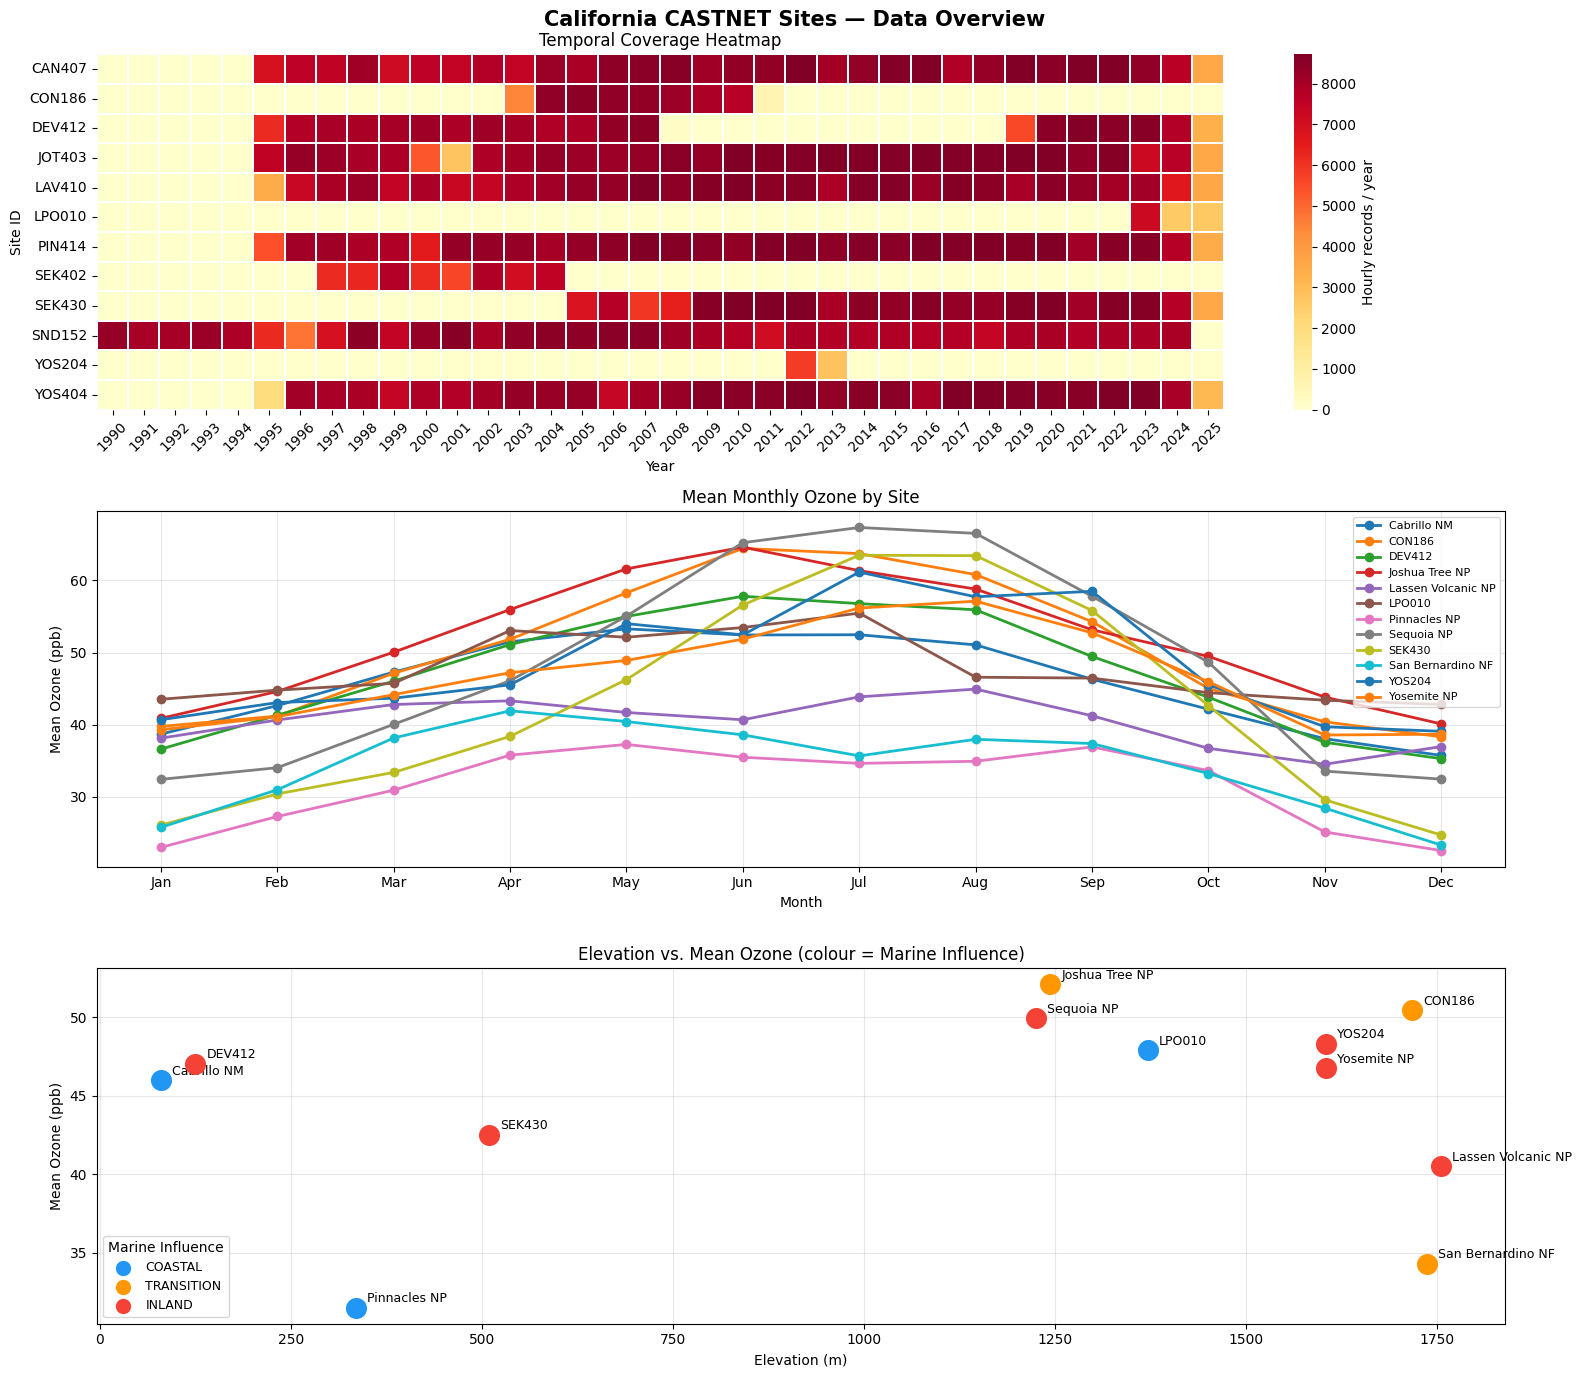

In [52]:
if not df_ozone.empty and 'DATE_TIME' in df_ozone.columns and 'SITE_ID' in df_ozone.columns:
    df_ozone['YEAR']  = df_ozone['DATE_TIME'].dt.year
    df_ozone['MONTH'] = df_ozone['DATE_TIME'].dt.month

    fig, axes = plt.subplots(3, 1, figsize=(16, 14))
    fig.suptitle('California CASTNET Sites — Data Overview', fontsize=15, fontweight='bold')

    pivot_count = df_ozone.groupby(['SITE_ID','YEAR']).size().unstack('YEAR', fill_value=0)
    sns.heatmap(pivot_count, ax=axes[0], cmap='YlOrRd', linewidths=0.3,
                linecolor='white', cbar_kws={'label':'Hourly records / year'})
    axes[0].set_title('Temporal Coverage Heatmap', fontsize=12)
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Site ID')
    axes[0].tick_params(axis='x', rotation=45)

    monthly_means = df_ozone.groupby(['SITE_ID','MONTH'])['OZONE'].mean().unstack('SITE_ID')
    for site in monthly_means.columns:
        meta = CA_SITE_REGISTRY.get(site, {})
        axes[1].plot(monthly_means.index, monthly_means[site],
                     marker='o', linewidth=2, label=meta.get('display_name', site))
    axes[1].set_title('Mean Monthly Ozone by Site', fontsize=12)
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Mean Ozone (ppb)')
    axes[1].set_xticks(range(1, 13))
    axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                              'Jul','Aug','Sep','Oct','Nov','Dec'])
    axes[1].legend(loc='upper right', fontsize=8)
    axes[1].grid(True, alpha=0.3)

    site_annual = df_ozone.groupby('SITE_ID')['OZONE'].mean().reset_index()
    site_annual.columns = ['SITE_ID','MEAN_OZONE']
    site_annual = site_annual.merge(
        df_site[['SITE_ID','ELEVATION_M','COAST_DIST_KM',
                 'DISPLAY_NAME','MARINE_INFLUENCE']].drop_duplicates(),
        on='SITE_ID', how='left'
    )
    colors = {'COASTAL':'#2196F3','TRANSITION':'#FF9800','INLAND':'#F44336'}
    for _, row in site_annual.iterrows():
        c = colors.get(row.get('MARINE_INFLUENCE','INLAND'), 'grey')
        axes[2].scatter(row['ELEVATION_M'], row['MEAN_OZONE'], c=c, s=200, zorder=5)
        axes[2].annotate(row.get('DISPLAY_NAME', row['SITE_ID']),
                         (row['ELEVATION_M'], row['MEAN_OZONE']),
                         textcoords='offset points', xytext=(8,4), fontsize=9)
    for mi, c in colors.items():
        axes[2].scatter([], [], c=c, label=mi, s=100)
    axes[2].set_title('Elevation vs. Mean Ozone (colour = Marine Influence)', fontsize=12)
    axes[2].set_xlabel('Elevation (m)')
    axes[2].set_ylabel('Mean Ozone (ppb)')
    axes[2].legend(title='Marine Influence', fontsize=9)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plot_path = os.path.join(PROCESSED_DIR, 'ca_ozone_overview.png')
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"Saved → {plot_path}")
    plt.show()
else:
    print("Ozone data not available for visualisation.")


## Section 15: Site Map — Elevation & Coast Distance

Saved → C:\MATH699P\Data\processed_data\california\ca_site_map.png


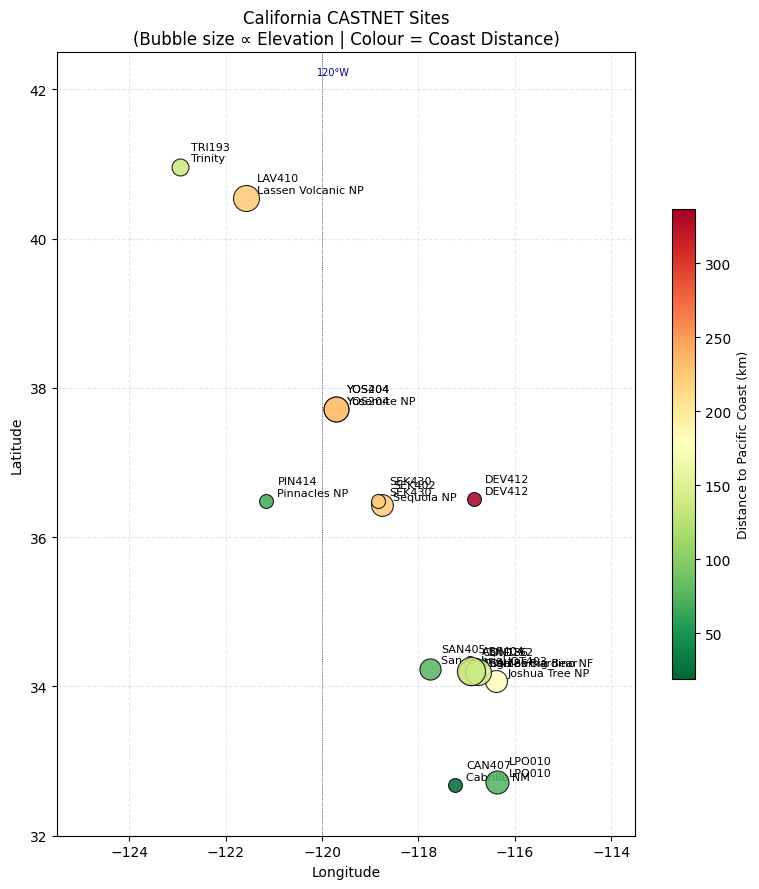


Static Site Features for Feature Engineering:
--------------------------------------------------------------------------------
SITE_ID       DISPLAY_NAME       LAT         LON  ELEVATION_M  COAST_DIST_KM MARINE_INFLUENCE TERRAIN_CLASS LAND_USE_CLASS    ELEVATION_BAND
 CON186             CON186 34.194050 -116.912979       1718.0     137.500000       TRANSITION           NaN            NaN HIGH (1000-2000m)
 DEV412             DEV412 36.508900 -116.847801        125.0     336.700012           INLAND           NaN            NaN       LOW (<500m)
 JOT403     Joshua Tree NP 34.069569 -116.388931       1244.0     179.699997       TRANSITION       EXPOSED   DESERT SHRUB HIGH (1000-2000m)
 LAV410 Lassen Volcanic NP 40.539989 -121.576462       1756.0     225.500000           INLAND       COMPLEX       FORESTED HIGH (1000-2000m)
 LPO010             LPO010 32.725189 -116.364410       1372.0      74.900002          COASTAL           NaN            NaN HIGH (1000-2000m)
 PIN414       Pinnacles NP

In [53]:
if not df_site.empty:
    fig, ax = plt.subplots(figsize=(8, 9))
    norm = plt.Normalize(df_site['COAST_DIST_KM'].min(), df_site['COAST_DIST_KM'].max())
    cmap = plt.cm.RdYlGn_r

    for _, row in df_site.iterrows():
        size = max(100, float(row['ELEVATION_M']) / 5)
        col  = cmap(norm(float(row['COAST_DIST_KM'])))
        ax.scatter(row['LON'], row['LAT'], s=size, c=[col],
                   edgecolors='black', linewidths=0.8, zorder=5, alpha=0.85)
        ax.annotate(f"{row['SITE_ID']}\n{row['DISPLAY_NAME']}",
                    (row['LON'], row['LAT']),
                    textcoords='offset points', xytext=(8,4), fontsize=8, ha='left')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, shrink=0.6).set_label('Distance to Pacific Coast (km)', fontsize=9)
    ax.set_xlim(-125.5, -113.5)
    ax.set_ylim(32.0, 42.5)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('California CASTNET Sites\n(Bubble size ∝ Elevation | Colour = Coast Distance)',
                 fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axvline(-120, color='navy', lw=0.5, linestyle=':')
    ax.text(-120.1, 42.2, '120°W', fontsize=7, color='navy')
    plt.tight_layout()
    map_path = os.path.join(PROCESSED_DIR, 'ca_site_map.png')
    plt.savefig(map_path, dpi=150, bbox_inches='tight')
    print(f"Saved → {map_path}")
    plt.show()

    print("\nStatic Site Features for Feature Engineering:")
    print("-" * 80)
    cols = ['SITE_ID','DISPLAY_NAME','LAT','LON','ELEVATION_M',
            'COAST_DIST_KM','MARINE_INFLUENCE','TERRAIN_CLASS','LAND_USE_CLASS','ELEVATION_BAND']
    print(df_site[[c for c in cols if c in df_site.columns]].to_string(index=False))


## Section 16: Save All Processed Data

In [54]:
def save_with_status(df, name, out_dir):
    """Save DataFrame to CSV; always writes headers even if empty, so downstream
    reads never crash on a missing file."""
    path = os.path.join(out_dir, f'{name}.csv')
    df.to_csv(path, index=False)
    if df.empty:
        print(f"  {name:<35s}  EMPTY SCHEMA saved  → {path}")
    else:
        size_mb = os.path.getsize(path) / (1024**2)
        print(f"  {name:<35s}  {len(df):>9,} rows  {size_mb:5.2f} MB  → {path}")

print("Saving all California data...")
print("-" * 75)
save_with_status(df_site,          'ca_site_metadata',         PROCESSED_DIR)
save_with_status(df_ozone,         'ca_ozone',                 PROCESSED_DIR)
save_with_status(df_gas,           'ca_hourly_gas',            PROCESSED_DIR)
save_with_status(df_drychem,       'ca_drychem',               PROCESSED_DIR)
save_with_status(df_wet,           'ca_wet_conc',              PROCESSED_DIR)
save_with_status(df_purpleair,     'ca_purpleair',             PROCESSED_DIR)
# ── Supplementary tables (empty schema saved even if absent) ────────────
save_with_status(df_drydep,        'ca_drydep_weekly',         PROCESSED_DIR)
save_with_status(df_total_dep,     'ca_total_deposition',      PROCESSED_DIR)
save_with_status(df_hist_hourly,   'ca_historic_avg_hourly',   PROCESSED_DIR)
save_with_status(df_hist_weekly,   'ca_historic_avg_weekly',   PROCESSED_DIR)
save_with_status(df_plant_summary, 'ca_plant_summary',         PROCESSED_DIR)
save_with_status(df_plant_detail,  'ca_plant_detail',          PROCESSED_DIR)

# Lightweight site feature lookup for feature_engineering.ipynb
site_cols = ['SITE_ID','LAT','LON','ELEVATION_M','COAST_DIST_KM',
             'MARINE_INFLUENCE','TERRAIN_CLASS','LAND_USE_CLASS','ELEVATION_BAND','REGION']
site_features = df_site[[c for c in site_cols if c in df_site.columns]].copy()
save_with_status(site_features, 'ca_site_static_features', PROCESSED_DIR)

print(f"\nAll files saved to: {PROCESSED_DIR}")


# ── Cross-dataset availability summary ───────────────────────────────────
if not df_site.empty:
    ca_avail = assess_data_availability(
        ca_sites_list = sorted(df_site['SITE_ID'].unique()),
        out_dir       = PROCESSED_DIR,
    )

Saving all California data...
---------------------------------------------------------------------------
  ca_site_metadata                            15 rows   0.00 MB  → C:\MATH699P\Data\processed_data\california\ca_site_metadata.csv
  ca_ozone                             1,960,605 rows  125.71 MB  → C:\MATH699P\Data\processed_data\california\ca_ozone.csv
  ca_hourly_gas                        EMPTY SCHEMA saved  → C:\MATH699P\Data\processed_data\california\ca_hourly_gas.csv
  ca_drychem                              12,193 rows   1.25 MB  → C:\MATH699P\Data\processed_data\california\ca_drychem.csv
  ca_wet_conc                          EMPTY SCHEMA saved  → C:\MATH699P\Data\processed_data\california\ca_wet_conc.csv
  ca_purpleair                            13,824 rows   0.52 MB  → C:\MATH699P\Data\processed_data\california\ca_purpleair.csv
  ca_drydep_weekly                         7,882 rows   0.45 MB  → C:\MATH699P\Data\processed_data\california\ca_drydep_weekly.csv
  ca_total_dep

## Section 17: Final Handoff Status

In [55]:
EXPECTED_OUTPUTS = {
    # ── Core modelling tables (required for feature engineering) ─────────
    'ca_site_static_features.csv' : 'Static site features (1 row/site)',
    'ca_ozone.csv'                : 'Hourly ozone target (ppb)',
    'ca_hourly_gas.csv'           : 'Hourly precursor gases (NO, NO2, NOy, SO2, CO)',
    'ca_drychem.csv'              : 'Weekly dry chemistry (SO4, NO3, NH4 …)',
    'ca_wet_conc.csv'             : 'Weekly wet chemistry (pH, SO4, NO3, precip)',
    'ca_purpleair.csv'            : 'Hourly PM2.5 wildfire proxy',
    # ── Supplementary tables (used by vegetation / deposition analysis) ──
    'ca_drydep_weekly.csv'        : 'Weekly dry deposition fluxes & Vd (optional)',
    'ca_total_deposition.csv'     : 'Annual total deposition budgets (optional)',
    'ca_historic_avg_hourly.csv'  : 'Climatological Vd by site/param/week/hour (optional)',
    'ca_historic_avg_weekly.csv'  : 'Climatological Vd by site/param/week (optional)',
    'ca_plant_summary.csv'        : 'Site plant species composition (optional)',
    'ca_plant_detail.csv'         : 'Site plant phenological detail (optional)',
}

print("=" * 80)
print("FINAL HANDOFF STATUS")
print("=" * 80)
all_ready = True
for fname, desc in EXPECTED_OUTPUTS.items():
    fpath = os.path.join(PROCESSED_DIR, fname)
    if os.path.exists(fpath):
        rows = sum(1 for _ in open(fpath)) - 1
        size = os.path.getsize(fpath) / (1024**2)
        empty_flag = "  ⚠ EMPTY SCHEMA" if rows == 0 else ""
        print(f"  ✅  {fname:<40s}  {rows:>10,} rows  {size:5.2f} MB{empty_flag}")
    else:
        print(f"  ❌  {fname:<40s}  MISSING")
        all_ready = False

print()
if all_ready:
    print("✅  All files present. Ready for feature_engineering.ipynb.")
else:
    print("⚠   Some files missing — check paths above.")

print()
print("For EMPTY SCHEMA files: the feature engineering notebook will create NaN")
print("columns. Download missing tables from https://www.epa.gov/castnet/castnet-data")
print()
print("Next step: feature_engineering.ipynb")
print("  - Load ca_ozone.csv as the hourly spine")
print("  - Left-join ca_hourly_gas.csv on SITE_ID + DATE_TIME")
print("  - Forward-fill ca_drychem.csv / ca_wet_conc.csv onto hourly timestamps")
print("  - Left-join ca_purpleair.csv on SITE_ID + DATE_TIME")
print("  - Merge ca_site_static_features.csv on SITE_ID (no time join needed)")


FINAL HANDOFF STATUS
  ✅  ca_site_static_features.csv                       15 rows   0.00 MB
  ✅  ca_ozone.csv                               1,960,605 rows  125.71 MB
  ✅  ca_hourly_gas.csv                                  0 rows   0.00 MB  ⚠ EMPTY SCHEMA
  ✅  ca_drychem.csv                                12,193 rows   1.25 MB
  ✅  ca_wet_conc.csv                                    0 rows   0.00 MB  ⚠ EMPTY SCHEMA
  ✅  ca_purpleair.csv                              13,824 rows   0.52 MB
  ✅  ca_drydep_weekly.csv                           7,882 rows   0.45 MB
  ✅  ca_total_deposition.csv                          590 rows   0.01 MB
  ✅  ca_historic_avg_hourly.csv                    50,880 rows   4.08 MB
  ✅  ca_historic_avg_weekly.csv                     2,108 rows   0.06 MB
  ✅  ca_plant_summary.csv                              46 rows   0.00 MB
  ✅  ca_plant_detail.csv                              190 rows   0.01 MB

✅  All files present. Ready for feature_engineering.ipynb.

For EMPTY

In [56]:
# ── Build coverage summary ────────────────────────────────────
coverage_rows = []
for sid in sorted(df_ozone['SITE_ID'].unique()):
    site_df = df_ozone[df_ozone['SITE_ID'] == sid]
    coverage_rows.append({
        'SITE_ID'   : sid,
        'first'     : site_df['DATE_TIME'].min().strftime('%Y-%m'),
        'last'      : site_df['DATE_TIME'].max().strftime('%Y-%m'),
        'n_rows'    : len(site_df),
        'n_years'   : site_df['DATE_TIME'].dt.year.nunique(),
        'pct_valid' : round(site_df['OZONE'].notna().mean(), 4),
    })
cov_df = pd.DataFrame(coverage_rows)
print(cov_df.to_string(index=False))


# ── DASHBOARD EXPORT ──────────────────────────────────────────
import json
from pathlib import Path

DASH_DIR = Path(r"C:\MATH699P\Data\dashboard_data")   # adjust path if needed
DASH_DIR.mkdir(exist_ok=True)

# Site metadata — enriched with actual year range from cov_df
cov_idx = cov_df.set_index('SITE_ID')
site_export = {}
for sid, meta in CA_SITE_REGISTRY.items():
    row = cov_idx.loc[sid] if sid in cov_idx.index else {}
    site_export[sid] = {
    "name"      : meta["display_name"],
    "lat"       : meta["lat"],
    "lon"       : meta["lon"],
    "elev"      : meta["elevation_m"],
    "coast_km"  : meta["coast_dist_km"],
    "marine"    : meta["marine_influence"],
    "region"    : meta.get("region", ""),
    "status"    : "ACTIVE",        # ← add this back; overwritten by gap fixes step
    "yr_start"  : int(row["first"][:4]) if isinstance(row, pd.Series) else 0,
    "yr_end"    : int(row["last"][:4])  if isinstance(row, pd.Series) else 0,
    "n_rows"    : int(row.get("n_rows", 0)),
    "pct_valid" : float(row.get("pct_valid", 0)),
}

with open(DASH_DIR / "site_metadata.json", "w") as f:
    json.dump(site_export, f, indent=2)

# Coverage audit
cov_df.to_csv(DASH_DIR / "coverage_audit.csv", index=False)

# Pipeline status
status = {}
try:
    with open(DASH_DIR / "pipeline_status.json") as f:
        status = json.load(f)
except FileNotFoundError:
    pass
status["data_extraction"] = {
    "status"    : "complete",
    "timestamp" : pd.Timestamp.now().isoformat(),
    "rows"      : len(df_ozone),
    "sites"     : sorted(df_ozone['SITE_ID'].unique().tolist()),
}
with open(DASH_DIR / "pipeline_status.json", "w") as f:
    json.dump(status, f, indent=2)

print("✅ Data extraction exported to dashboard_data/")

SITE_ID   first    last  n_rows  n_years  pct_valid
 CAN407 1995-01 2025-05  246689       31        1.0
 CON186 2003-06 2011-01   62570        9        1.0
 DEV412 1995-01 2025-05  153887       21        1.0
 JOT403 1995-02 2025-05  244399       31        1.0
 LAV410 1995-07 2025-05  242746       31        1.0
 LPO010 2023-01 2025-05   12496        3        1.0
 PIN414 1995-05 2025-05  250345       31        1.0
 SEK402 1997-02 2004-12   54390        8        1.0
 SEK430 2005-03 2025-05  165301       21        1.0
 SND152 1990-01 2024-12  274143       35        1.0
 YOS204 2012-04 2013-04    8631        2        1.0
 YOS404 1995-10 2025-05  245008       31        1.0
✅ Data extraction exported to dashboard_data/
